# Problem Statement

A bike-sharing system is a service in which bikes are made available for shared
use to individuals on a short term basis for a price or free. Many bike share systems allow people to borrow a bike from a "dock" which is usually computer-controlled wherein the user enters the payment information, and the system unlocks it. This bike can then be returned to another dock belonging to the same system.


A US bike-sharing provider BoomBikes has recently suffered considerable dips in their revenues due to the ongoing Corona pandemic. The company is finding it very difficult to sustain in the current market scenario. So, it has decided to come up with a mindful business plan to be able to accelerate its revenue as soon as the ongoing lockdown comes to an end, and the economy restores to a healthy state.


In such an attempt, BoomBikes aspires to understand the demand for shared bikes among the people after this ongoing quarantine situation ends across the nation due to Covid-19. They have planned this to prepare themselves to cater to the people's needs once the situation gets better all around and stand out from other service providers and make huge profits.


They have contracted a consulting company to understand the factors on which the demand for these shared bikes depends. Specifically, they want to understand the factors affecting the demand for these shared bikes in the American market. The company wants to know:

Which variables are significant in predicting the demand for shared bikes.
How well those variables describe the bike demands
Based on various meteorological surveys and people's styles, the service provider firm has gathered a large dataset on daily bike demands across the American market based on some factors.


# Business Goal:

You are required to model the demand for shared bikes with the available independent variables. It will be used by the management to understand how exactly the demands vary with different features. They can accordingly manipulate the business strategy to meet the demand levels and meet the customer's expectations. Further, the model will be a good way for management to understand the demand dynamics of a new market.

# Understand the Problem (Business → ML Mapping)

 Problem Solving a supervised regression method:
    
    1. Target variable (y): Bike demand (count of rentals)
    2. Input features (X): Weather, season, temperature, working day, etc.

 Goals:

  1. Identify important variables
  2. Build a model that explains demand
  3. Help business increase revenue

# Step-By-Step Solution Approach

1. Data Understanding
2. Data Cleaning
3. Exploratory Data Analysis (EDA)
4. Features Engineering
5. Model Buliding
6. Model Evaluation
7. Features Importance
8. Improve The Model
9. Businees Insights  

## 1. Data Understanding

In [1]:
# NumPy is used for numerical computations (arrays, matrices, math operations)
import numpy as np

# Pandas is used for data manipulation and analysis (DataFrames, CSV handling)
import pandas as pd

# Matplotlib is used for basic data visualization (plots, graphs)
import matplotlib.pyplot as plt

# Seaborn is built on top of matplotlib, used for advanced statistical visualizations
import seaborn as sns

# Import entire linear_model module from sklearn: gives access to multiple models like Ridge, Lasso, LogisticRegression, etc.
from sklearn import linear_model

# Import LinearRegression specifically: used to build a regression model to predict continuous values (like bike demand)
from sklearn.linear_model import LinearRegression

In [2]:
# Import warnings module used to control warning messages (like deprecation, runtime warnings)
import warnings

# Ignore all warnings suppresses warning messages so they don't clutter the output
warnings.filterwarnings('ignore')

In [3]:
# Reading the dataset
Bike_Sharing_Day = pd.read_csv("/content/day.csv")

# Look at the first few rows
Bike_Sharing_Day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2018,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,02-01-2018,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,03-01-2018,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,04-01-2018,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,05-01-2018,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600


In [4]:
# Look at the number of rows and columns in the dataset
Bike_Sharing_Day.shape

(730, 16)

In [5]:
# Understanding the feature names in the dataset
Bike_Sharing_Day.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

In [6]:
# Getting insights of the features
Bike_Sharing_Day.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000
mean,365.500000,2.498630,0.500000,6.526027,0.028767,2.997260,0.683562,1.394521,20.319259,23.726322,62.765175,12.763620,849.249315,3658.757534,4508.006849
std,210.877136,1.110184,0.500343,3.450215,0.167266,2.006161,0.465405,0.544807,7.506729,8.150308,14.237589,5.195841,686.479875,1559.758728,1936.011647
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.424346,3.953480,0.000000,1.500244,2.000000,20.000000,22.000000
25%,183.250000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,13.811885,16.889713,52.000000,9.041650,316.250000,2502.250000,3169.750000
50%,365.500000,3.000000,0.500000,7.000000,0.000000,3.000000,1.000000,1.000000,20.465826,24.368225,62.625000,12.125325,717.000000,3664.500000,4548.500000
75%,547.750000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,26.880615,30.445775,72.989575,15.625589,1096.500000,4783.250000,5966.000000
max,730.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,35.328347,42.044800,97.250000,34.000021,3410.000000,6946.000000,8714.000000


In [7]:
# Summary of the dataset
Bike_Sharing_Day.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     730 non-null    int64  
 1   dteday      730 non-null    object 
 2   season      730 non-null    int64  
 3   yr          730 non-null    int64  
 4   mnth        730 non-null    int64  
 5   holiday     730 non-null    int64  
 6   weekday     730 non-null    int64  
 7   workingday  730 non-null    int64  
 8   weathersit  730 non-null    int64  
 9   temp        730 non-null    float64
 10  atemp       730 non-null    float64
 11  hum         730 non-null    float64
 12  windspeed   730 non-null    float64
 13  casual      730 non-null    int64  
 14  registered  730 non-null    int64  
 15  cnt         730 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.4+ KB


## 2. Data Cleaning

#### Understanding the Data Dictionary and parts of Data Preparation

Data dictionary contains the meaning of various attributes; some of which are explored and manipulated here:

In [8]:
# Convert numeric season values into categorical string labels
# Reason: Numeric values (1,2,3,4) may incorrectly imply an order or magnitude, which can mislead machine learning models into thinking 'winter > summer', etc.

# Replace value 1 with 'spring'
Bike_Sharing_Day.loc[(Bike_Sharing_Day['season'] == 1), 'season'] = 'spring'

# Replace value 2 with 'summer'
Bike_Sharing_Day.loc[(Bike_Sharing_Day['season'] == 2), 'season'] = 'summer'

# Replace value 3 with 'fall'
Bike_Sharing_Day.loc[(Bike_Sharing_Day['season'] == 3), 'season'] = 'fall'

# Replace value 4 with 'winter'
Bike_Sharing_Day.loc[(Bike_Sharing_Day['season'] == 4), 'season'] = 'winter'

In [9]:
# Convert 'season' column to categorical type and count frequency of each category this helps verify whether the earlier mapping (1→spring, etc.) was done correctly
Bike_Sharing_Day['season'].astype('category').value_counts()

,count
season,
fall,188
summer,184
spring,180
winter,178


In [10]:
# Convert 'yr' column into categorical type and count occurrences of each year
# 'yr' is encoded as:
# 0 → 2018
# 1 → 2019
Bike_Sharing_Day['yr'].astype('category').value_counts()

,count
yr,
0,365
1,365


In [11]:
# Convert numeric month values into categorical string labels (Jan, Feb, etc.)
# Reason: Numeric months (1–12) may falsely imply ordinal relationships (e.g., Dec > Jan),

# Define a function to map numeric month values to their corresponding names
def object_map(x):
    # Replace numbers with month abbreviations
    return x.map({
        1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr',
        5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug',
        9: 'Sept', 10: 'Oct', 11: 'Nov', 12: 'Dec'
    })

# Apply the mapping function to the 'mnth' column using DataFrame apply to transform values into categorical labels
Bike_Sharing_Day[['mnth']] = Bike_Sharing_Day[['mnth']].apply(object_map)

In [12]:
# Convert 'mnth' (month) column into categorical type and count frequency of each month this is done to verify whether the numeric-to-string mapping (1→Jan, etc.) was applied correctly
Bike_Sharing_Day['mnth'].astype('category').value_counts()

,count
mnth,
Aug,62
Dec,62
Jul,62
Jan,62
Oct,62
May,62
Mar,62
Apr,60
Nov,60


In [13]:
# Convert 'holiday' column into categorical type and count frequency of each category
# 'holiday' is encoded as:
# 0 → Not a holiday
# 1 → Holiday
# this step verifies the correctness of the data and checks distribution
Bike_Sharing_Day['holiday'].astype('category').value_counts()

,count
holiday,
0,709
1,21


In [14]:
# Convert numeric weekday values into categorical string labels (Mon, Tues, etc.)
# Reason: Numeric encoding (0–6) may falsely imply order or magnitude,

# Define a function to map numeric weekday values to actual day names
def str_map(x):
    # mapping based on dataset encoding: 0 → Tues, 1 → Wed, ..., 6 → Mon
    return x.map({1: 'Wed', 2: 'Thurs', 3: 'Fri', 4: 'Sat', 5: 'Sun', 6: 'Mon', 0: 'Tues'})

# Apply the mapping function to the 'weekday' column converts numeric values into categorical weekday names
Bike_Sharing_Day[['weekday']] = Bike_Sharing_Day[['weekday']].apply(str_map)

In [15]:
# Convert 'weekday' column into categorical type and count frequency of each weekday this step is used to verify whether numeric-to-string mapping (0→Tues, etc.) was done correctly
Bike_Sharing_Day['weekday'].astype('category').value_counts()

,count
weekday,
Mon,105
Tues,105
Wed,105
Thurs,104
Sat,104
Sun,104
Fri,103


In [16]:
# Convert 'workingday' column into categorical type and count frequency of each category
# 'workingday' is encoded as:
# 1 → Working day (not a weekend or holiday)
# 0 → Non-working day (weekend or holiday)
# this step verifies correctness and checks distribution of working vs non-working days
Bike_Sharing_Day['workingday'].astype('category').value_counts()

,count
workingday,
1,499
0,231


In [17]:
# Convert numeric weather situation codes into readable categorical labels (A, B, C, D)
# Reason: Numeric values (1–4) may imply an incorrect order or magnitude while these are actually categorical weather conditions
# 1 → Clear / Partly Cloudy weather (best conditions)
Bike_Sharing_Day.loc[(Bike_Sharing_Day['weathersit'] == 1), 'weathersit'] = 'A'
# 2 → Misty / Cloudy weather (moderate conditions)
Bike_Sharing_Day.loc[(Bike_Sharing_Day['weathersit'] == 2), 'weathersit'] = 'B'
# 3 → Light Snow / Rain / Thunderstorm (bad conditions)
Bike_Sharing_Day.loc[(Bike_Sharing_Day['weathersit'] == 3), 'weathersit'] = 'C'
# 4 → Heavy Rain / Snow / Fog (worst conditions)
Bike_Sharing_Day.loc[(Bike_Sharing_Day['weathersit'] == 4), 'weathersit'] = 'D'

In [18]:
# Get all unique weather categories present in the dataset this helps verify whether the mapping (1→A, 2→B, etc.) was applied correctly
Bike_Sharing_Day['weathersit'].unique()

array(['B', 'A', 'C'], dtype=object)

In [19]:
# Convert 'weathersit' column into categorical type and count frequency of each weather category this helps verify distribution of weather conditions after mapping (1→A, 2→B, etc.)
Bike_Sharing_Day['weathersit'].astype('category').value_counts()

,count
weathersit,
A,463
B,246
C,21


## 3. Exploratory Data Analysis (EDA)

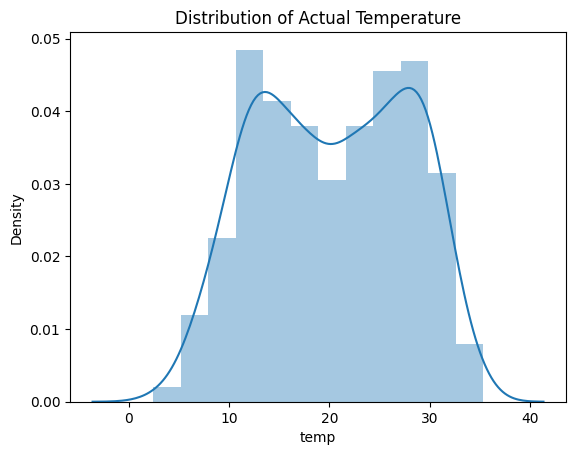

In [20]:
# Plot the distribution of the 'temp' (temperature) variable helps understand how actual temperature is distributed (normal, skewed, etc.)
sns.distplot(Bike_Sharing_Day['temp'])

# Title
plt.title("Distribution of Actual Temperature")

# Display the plot
plt.show()

### If they show this plot, say:

Temperature distribution appears slightly bimodal, indicating seasonal variations in the dataset. Most values lie within a moderate range, suggesting realistic environmental conditions. this also implies that bike demand may have a non-linear relationship with temperature, making polynomial features or non-linear models more suitable

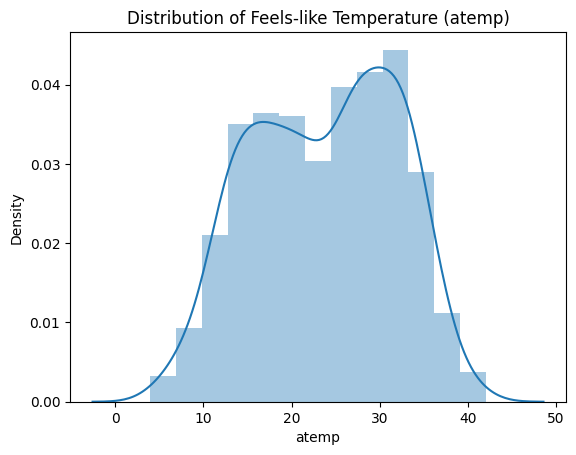

In [21]:
# Plot the distribution of 'atemp' (feels-like temperature) this represents perceived temperature by users, which may influence demand more than actual temp
sns.distplot(Bike_Sharing_Day['atemp'])

# Title
plt.title("Distribution of Feels-like Temperature (atemp)")

# Display the plot
plt.show()

## If they show this plot, say:

Distribution of feels-like temperature is slightly bimodal, indicating seasonal variation. Compared to actual temperature, it is smoother and more representative of human comfort. This makes it a stronger predictor of bike demand. However, since it is highly correlated with temperature, it may introduce multicollinearity in linear models, so feature selection or regularization is required.

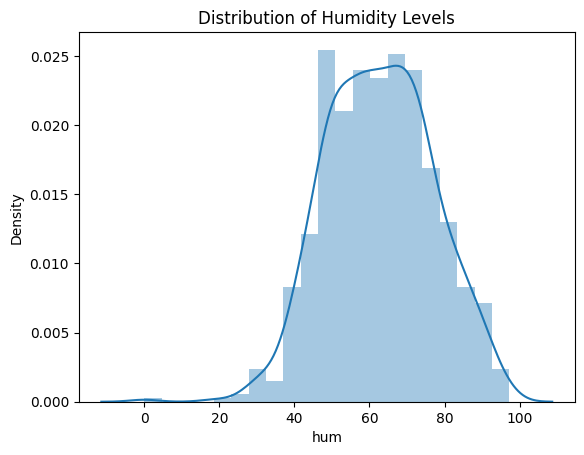

In [22]:
# Plot the distribution of 'hum' (humidity) helps analyze how humidity levels vary and their potential impact on bike usage
sns.distplot(Bike_Sharing_Day['hum'])

# Title
plt.title("Distribution of Humidity Levels")

# Display the plot
plt.show()

## If they show this plot, say:

Humidity distribution is approximately normal, centered around 60–70%, indicating that most days experience moderate to high humidity. There is a slight right skew, suggesting more high-humidity days. Since humidity negatively impacts bike demand, this distribution implies that demand suppression due to humidity is a consistent factor in the dataset

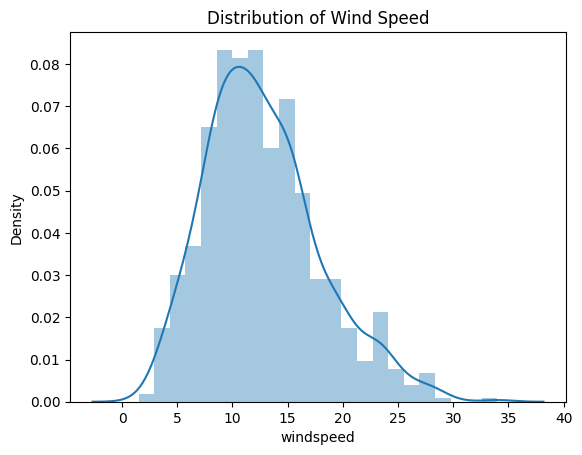

In [23]:
# Plot the distribution of 'windspeed' useful to understand how wind conditions vary and whether extreme wind affects usage
sns.distplot(Bike_Sharing_Day['windspeed'])

# Title
plt.title("Distribution of Wind Speed")

# Display the plot
plt.show()

## If they show this plot, say:

Humidity distribution appears approximately normal with most values concentrated between 50–80%. Since high humidity reduces comfort, it is expected to have a negative correlation with bike demand. The feature is well-behaved and suitable for linear modeling, although interaction effects with temperature may further improve predictions

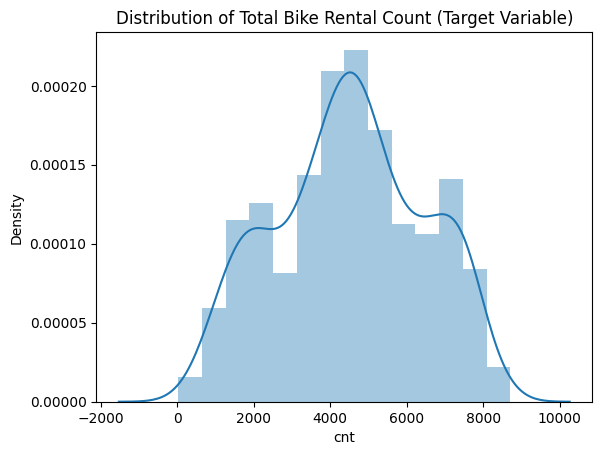

In [24]:
# Plot the distribution of 'cnt' (target variable) this is the total number of bike rentals (casual + registered) important for understanding demand distribution and model behavior
sns.distplot(Bike_Sharing_Day['cnt'])

# Title
plt.title("Distribution of Total Bike Rental Count (Target Variable)")

# Display the plot
plt.show()

## If they show this plot, say:

Target variable shows an approximately normal distribution with slight right skew, indicating most days have moderate demand with occasional high-demand spikes. This suggests that demand is influenced by multiple external factors such as weather and seasonality. The distribution is suitable for regression modeling, although log transformation can be applied to handle skewness and improve performance

In [25]:
# Convert 'dteday' column to datetime format this ensures the column is treated as a proper date instead of a string/object
Bike_Sharing_Day['dteday'] = Bike_Sharing_Day['dteday'].astype('datetime64[ns]')

In [26]:
# Select only categorical (non-numeric, non-datetime) columns from the dataset
# exclude=['float64','datetime64','int64'] removes:
# - float64 → continuous numerical features
# - int64 → numerical features (including binary/encoded ones)
# - datetime64 → date/time columns
# Remaining columns are typically object/category type → categorical variables
Bike_Sharing_Day_categorical = Bike_Sharing_Day.select_dtypes(exclude=['float64', 'datetime64', 'int64'])

# Print the names of categorical columns helps identify which features need encoding (e.g., one-hot encoding)
print(Bike_Sharing_Day_categorical.columns)

Index(['season', 'mnth', 'weekday', 'weathersit'], dtype='object')


In [27]:
# Display the dataframe containing only categorical features this dataframe was previously created by selecting non-numeric columns
Bike_Sharing_Day_categorical

,season,mnth,weekday,weathersit
0,spring,Jan,Mon,B
1,spring,Jan,Tues,B
2,spring,Jan,Wed,A
3,spring,Jan,Thurs,A
4,spring,Jan,Fri,A
...,...,...,...,...
725,spring,Dec,Sat,B
726,spring,Dec,Sun,B
727,spring,Dec,Mon,B
728,spring,Dec,Tues,A


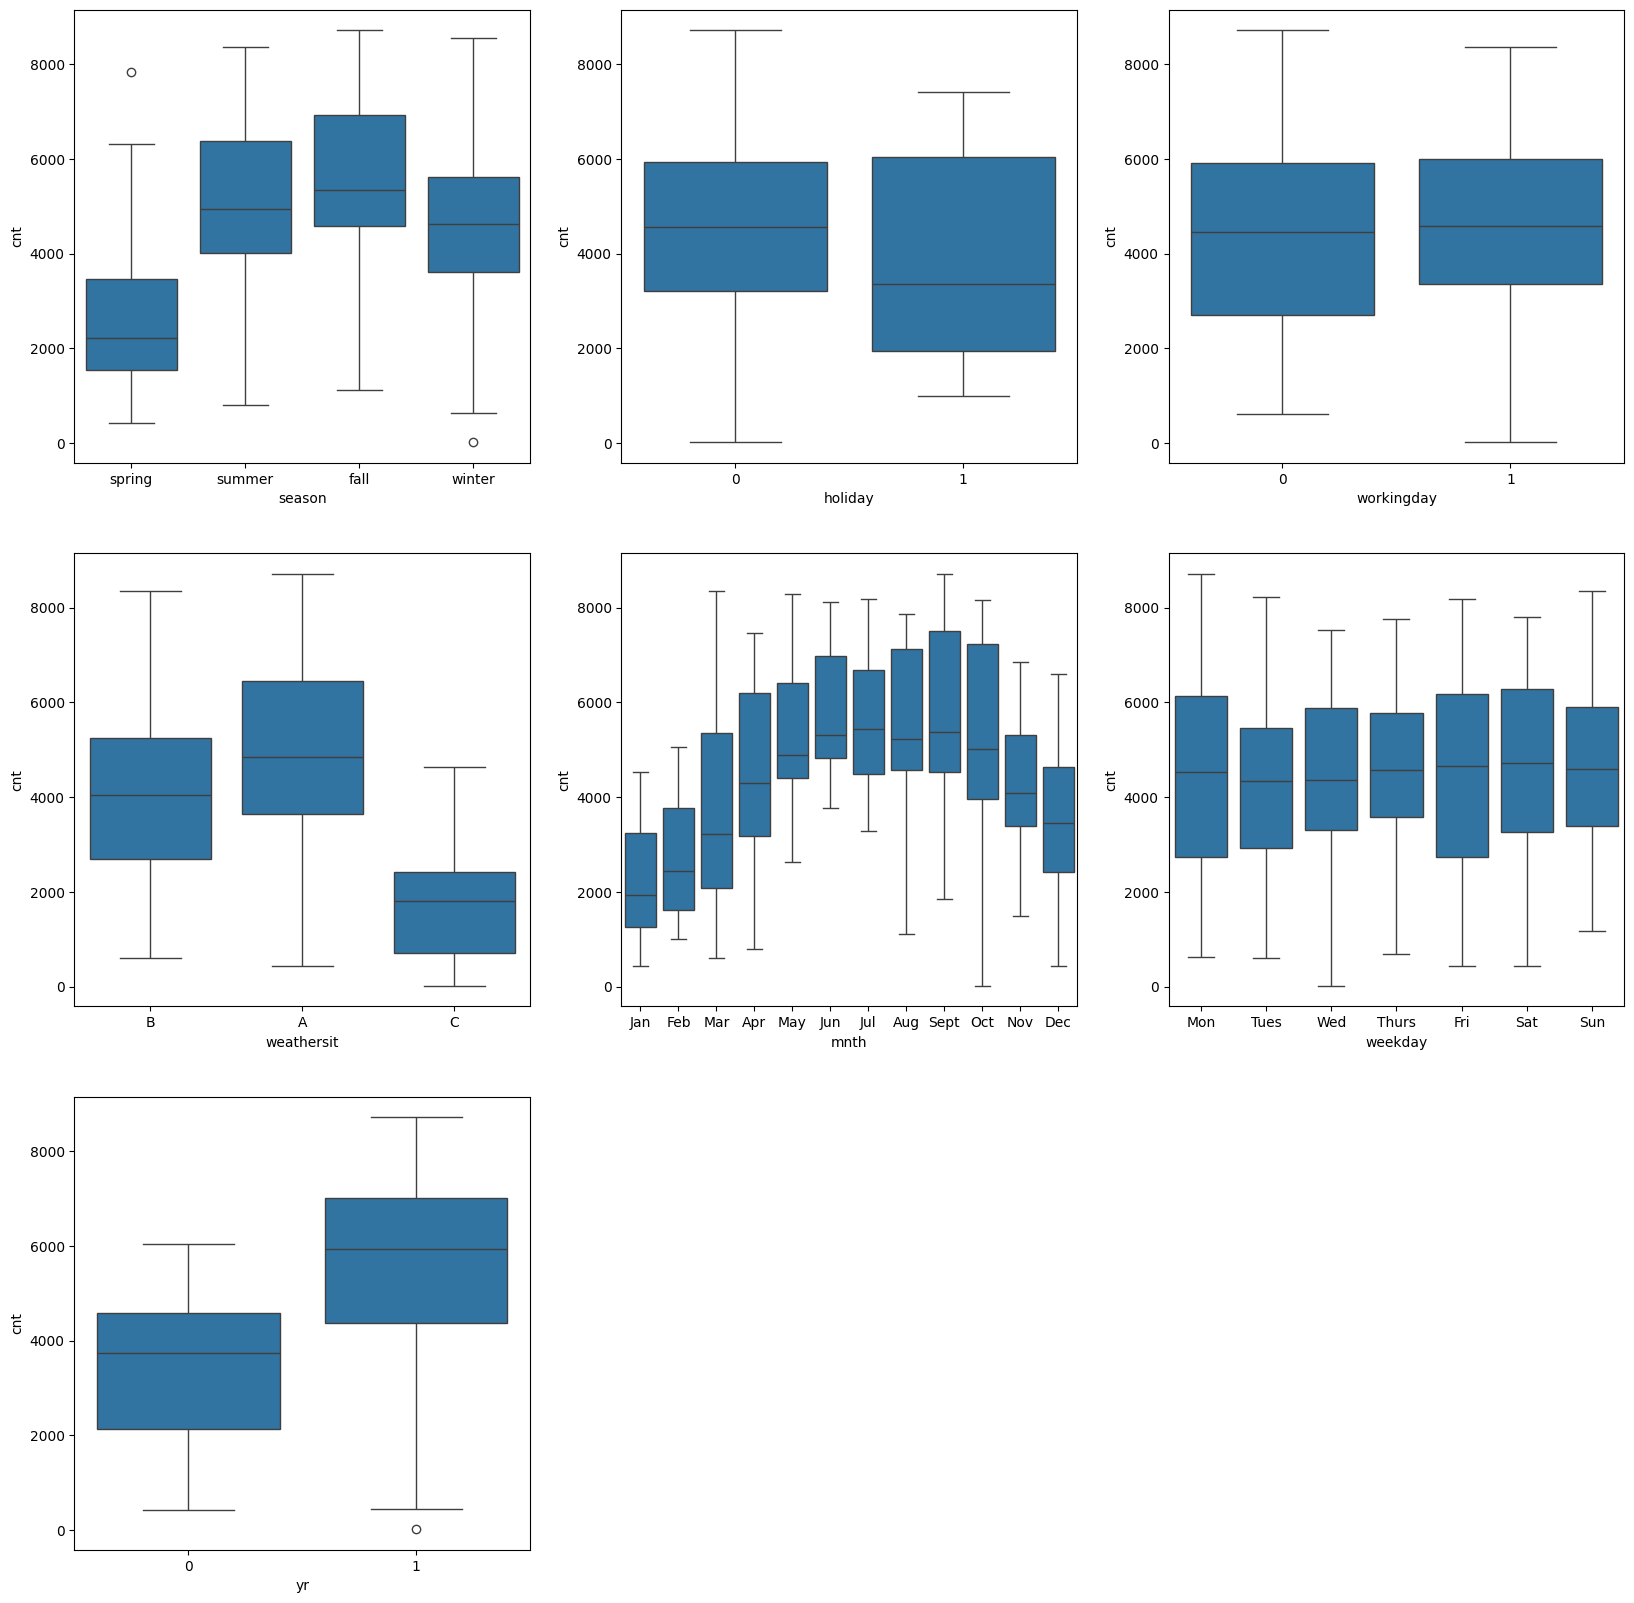

In [28]:
# Create a large figure to display multiple boxplots clearly
# figsize(20,20) ensures readability of all subplots
plt.figure(figsize=(20, 20))

# -------------------- Boxplot 1 --------------------
# Analyze how bike demand (cnt) varies across different seasons
plt.subplot(3,3,1)
sns.boxplot(x='season', y='cnt', data=Bike_Sharing_Day)

# -------------------- Boxplot 2 --------------------
# Compare bike demand on holidays vs non-holidays
plt.subplot(3,3,2)
sns.boxplot(x='holiday', y='cnt', data=Bike_Sharing_Day)

# -------------------- Boxplot 3 --------------------
# Compare demand on working days vs non-working days
plt.subplot(3,3,3)
sns.boxplot(x='workingday', y='cnt', data=Bike_Sharing_Day)

# -------------------- Boxplot 4 --------------------
# Analyze impact of weather conditions on bike demand
plt.subplot(3,3,4)
sns.boxplot(x='weathersit', y='cnt', data=Bike_Sharing_Day)

# -------------------- Boxplot 5 --------------------
# Analyze monthly trends in bike demand (seasonality)
plt.subplot(3,3,5)
sns.boxplot(x='mnth', y='cnt', data=Bike_Sharing_Day)

# -------------------- Boxplot 6 --------------------
# Analyze how demand varies across weekdays
plt.subplot(3,3,6)
sns.boxplot(x='weekday', y='cnt', data=Bike_Sharing_Day)

# -------------------- Boxplot 7 --------------------
# Compare demand across years (growth trend)
plt.subplot(3,3,7)
sns.boxplot(x='yr', y='cnt', data=Bike_Sharing_Day)

# Display all plots created above
plt.show()

## If they show this plot, say:

From the boxplots, observe that bike demand is highly influenced by weather conditions and seasonality, with peak usage during clear weather and fall season. Demand is significantly lower during holidays and adverse weather conditions. Additionally, there is a clear upward trend across years, indicating business growth. Weekday has minimal impact, suggesting demand is relatively consistent throughout the week

In [29]:
# List of numerical variables currently stored as integers these represent continuous/count data (not categorical)
IntVariableList = ["casual", "registered", "cnt"]

# Convert selected integer columns to float type
# Reason:
# - ensures consistent numerical datatype for modeling
# - helps distinguish them from binary categorical variables (0/1)
Bike_Sharing_Day['casual'] = Bike_Sharing_Day['casual'].astype('float')
Bike_Sharing_Day['registered'] = Bike_Sharing_Day['registered'].astype('float')
Bike_Sharing_Day['cnt'] = Bike_Sharing_Day['cnt'].astype('float')

# Display first few rows of the dataset to verify changes
Bike_Sharing_Day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2018-01-01,spring,0,Jan,0,Mon,0,B,14.110847,18.18125,80.5833,10.749882,331.0,654.0,985.0
1,2,2018-02-01,spring,0,Jan,0,Tues,0,B,14.902598,17.68695,69.6087,16.652113,131.0,670.0,801.0
2,3,2018-03-01,spring,0,Jan,0,Wed,1,A,8.050924,9.47025,43.7273,16.636703,120.0,1229.0,1349.0
3,4,2018-04-01,spring,0,Jan,0,Thurs,1,A,8.200000,10.60610,59.0435,10.739832,108.0,1454.0,1562.0
4,5,2018-05-01,spring,0,Jan,0,Fri,1,A,9.305237,11.46350,43.6957,12.522300,82.0,1518.0,1600.0


In [30]:
# Select all numerical variables (float type) from the dataset include=['float64'] filters only continuous numeric features these are the variables typically used for regression modeling
Bike_Sharing_Day_numeric = Bike_Sharing_Day.select_dtypes(include=['float64'])

# Display first few rows of numeric dataset helps verify selected columns and inspect values
Bike_Sharing_Day_numeric.head()

,temp,atemp,hum,windspeed,casual,registered,cnt
0,14.110847,18.18125,80.5833,10.749882,331.0,654.0,985.0
1,14.902598,17.68695,69.6087,16.652113,131.0,670.0,801.0
2,8.050924,9.47025,43.7273,16.636703,120.0,1229.0,1349.0
3,8.200000,10.60610,59.0435,10.739832,108.0,1454.0,1562.0
4,9.305237,11.46350,43.6957,12.522300,82.0,1518.0,1600.0


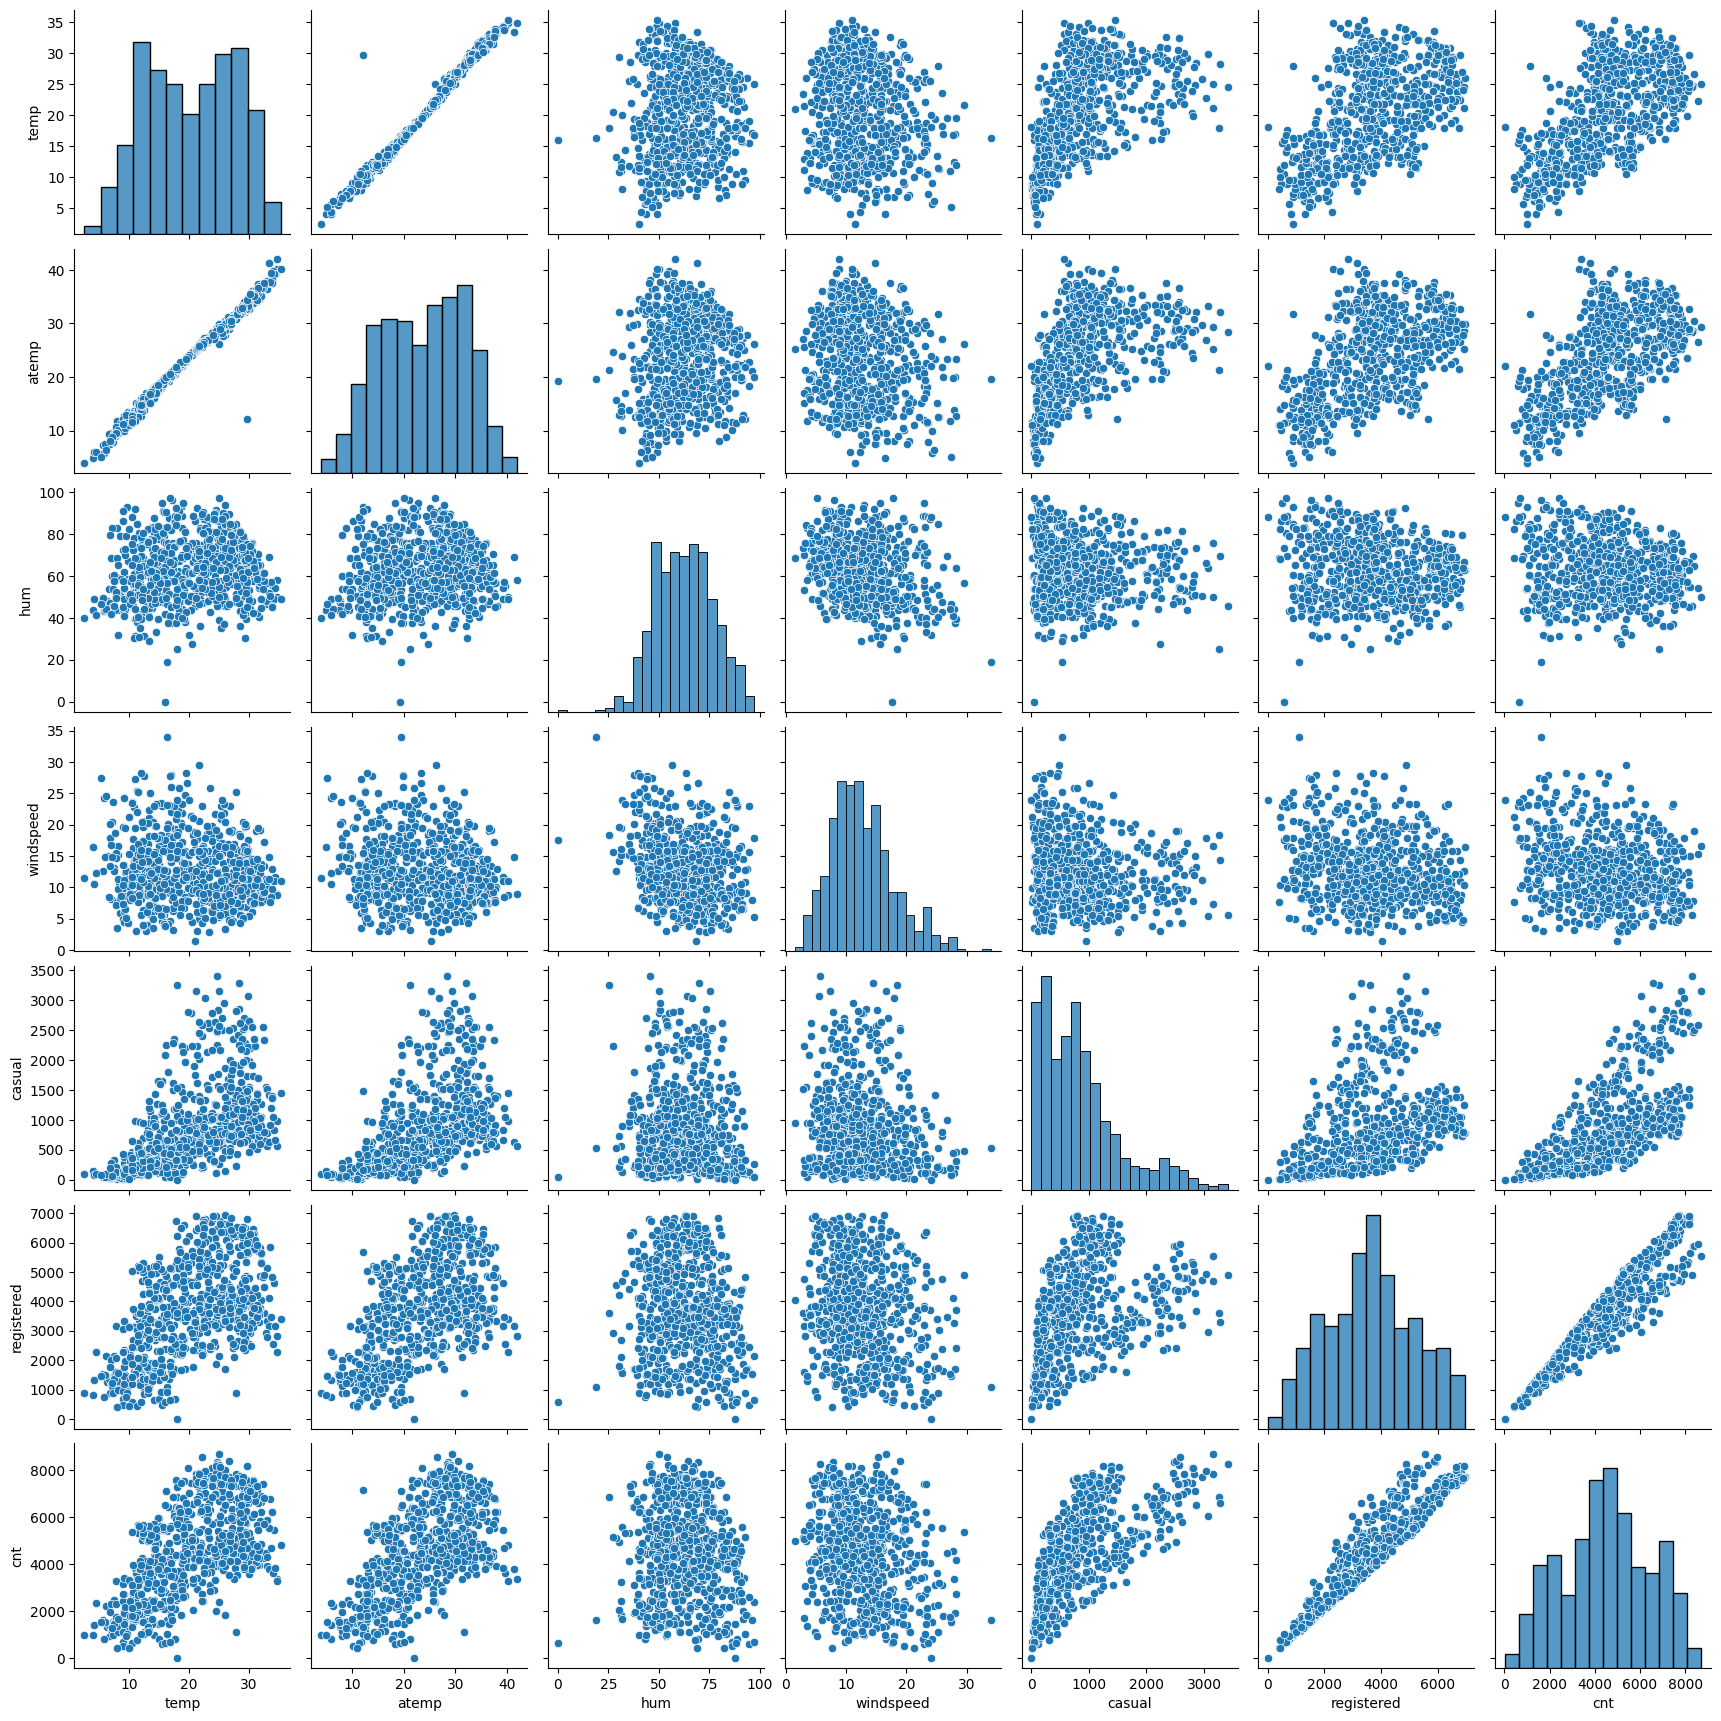

In [31]:
# Create pairwise scatter plots for all numeric variables this visualizes relationships between every pair of numerical features
sns.pairplot(Bike_Sharing_Day_numeric)

# Display the plot
plt.show()

## If they show this plot, say:

From the pairwise scatter plot analysis, several important insights can be derived regarding feature relationships and their impact on bike demand. Firstly, there is a near-perfect linear relationship between the target variable cnt and the variables casual and registered, which indicates data leakage since cnt is the sum of these two. Therefore, both features must be excluded from the model to ensure generalization.

Secondly, a very strong positive correlation is observed between temp and atemp, suggesting multicollinearity. Since atemp better captures human-perceived temperature, it is more meaningful to retain atemp and drop temp.

Further, atemp shows a strong positive relationship with cnt, indicating that higher perceived temperature leads to increased bike usage. In contrast, humidity exhibits a negative correlation with demand, implying that higher humidity reduces comfort and usage. Wind speed shows a weak and scattered relationship with the target, suggesting limited predictive power.

Overall, the analysis highlights that bike demand is primarily driven by weather-related factors, especially perceived temperature and humidity, while also emphasizing the importance of avoiding data leakage and multicollinearity in model building.

In [32]:
# Compute the correlation matrix for all numerical variables this calculates pairwise correlation coefficients (usually Pearson correlation) between all numeric features in the dataset
cor = Bike_Sharing_Day_numeric.corr()

# Display the correlation matrix each value ranges from -1 to +1:
# +1 → strong positive correlation
# -1 → strong negative correlation
#  0 → no correlation
cor

,temp,atemp,hum,windspeed,casual,registered,cnt
temp,1.000000,0.991696,0.128565,-0.158186,0.542731,0.539436,0.627044
atemp,0.991696,1.000000,0.141512,-0.183876,0.543362,0.543678,0.630685
hum,0.128565,0.141512,1.000000,-0.248506,-0.075211,-0.089212,-0.098543
windspeed,-0.158186,-0.183876,-0.248506,1.000000,-0.167995,-0.217914,-0.235132
casual,0.542731,0.543362,-0.075211,-0.167995,1.000000,0.394137,0.672123
registered,0.539436,0.543678,-0.089212,-0.217914,0.394137,1.000000,0.945411
cnt,0.627044,0.630685,-0.098543,-0.235132,0.672123,0.945411,1.000000


<Axes: >

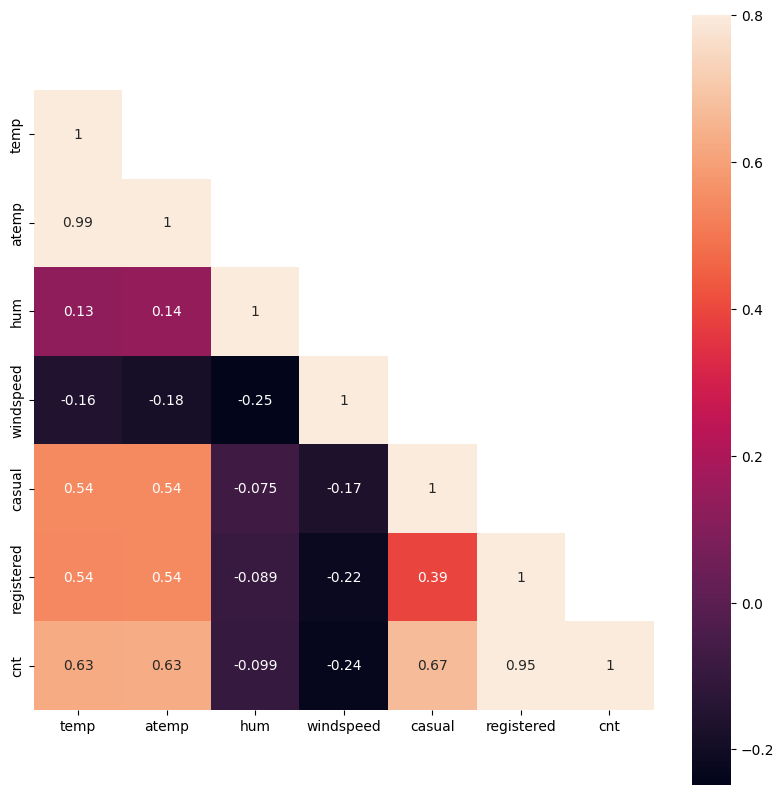

In [33]:
# Create a mask to display only the upper triangle of the correlation matrix this avoids duplicate values since correlation matrix is symmetric
mask = np.array(cor)
mask[np.tril_indices_from(mask)] = False

# Create a figure and axis for the heatmap
fig, ax = plt.subplots()

# Set figure size for better readability
fig.set_size_inches(10, 10)

# Plot heatmap of correlation matrix
sns.heatmap(cor, mask=mask, vmax=.8, square=True, annot=True)

## If they show this plot, say:

From the correlation matrix, observe strong multicollinearity between temperature and feels-like temperature, so one should be removed. Additionally, casual and registered variables show very high correlation with the target, indicating data leakage, and must be excluded. The most important predictors are temperature-related features, while humidity and windspeed show weaker negative relationships with demand. This analysis helps in selecting relevant features and ensuring model stability.

## 4. Feature Engineering

### Final  Feature Selection  

  - 1. Drop: casual, registered, temp
  - 2. Keep: atemp, hum, windspeed + categorical features (season, weathersit, yr, etc.)

In [34]:
# Define list of features to drop
# 1. 'casual' and 'registered' are removed to avoid data leakage (cnt = casual + registered)
# 2. 'temp' is removed due to high multicollinearity with 'atemp'
drop_cols = ['casual', 'registered', 'temp']

# Drop the specified columns from the dataset this step ensures only relevant and non-redundant features are used for modeling
Bike_Sharing_Day = Bike_Sharing_Day.drop(columns=drop_cols)

# Display first few rows of the updated dataset used to verify that columns were successfully removed
Bike_Sharing_Day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,atemp,hum,windspeed,cnt
0,1,2018-01-01,spring,0,Jan,0,Mon,0,B,18.18125,80.5833,10.749882,985.0
1,2,2018-02-01,spring,0,Jan,0,Tues,0,B,17.68695,69.6087,16.652113,801.0
2,3,2018-03-01,spring,0,Jan,0,Wed,1,A,9.47025,43.7273,16.636703,1349.0
3,4,2018-04-01,spring,0,Jan,0,Thurs,1,A,10.60610,59.0435,10.739832,1562.0
4,5,2018-05-01,spring,0,Jan,0,Fri,1,A,11.46350,43.6957,12.522300,1600.0


In [35]:
# Select all categorical variables from the dataset
Bike_Sharing_Day_categorical = Bike_Sharing_Day.select_dtypes(include=['object'])

In [36]:
# Convert categorical variables into dummy/indicator variables (One-Hot Encoding)
# pd.get_dummies() transforms each category into separate binary (0/1) columns
# drop_first=True avoids the dummy variable trap (multicollinearity in regression)
Bike_Sharing_Day_dummies = pd.get_dummies(Bike_Sharing_Day_categorical, drop_first=True)

# Display first few rows of the encoded dataset used to verify that categorical variables are correctly converted into numeric format
Bike_Sharing_Day_dummies.head()

,season_spring,season_summer,season_winter,mnth_Aug,mnth_Dec,mnth_Feb,mnth_Jan,mnth_Jul,mnth_Jun,mnth_Mar,...,mnth_Oct,mnth_Sept,weekday_Mon,weekday_Sat,weekday_Sun,weekday_Thurs,weekday_Tues,weekday_Wed,weathersit_B,weathersit_C
0,True,False,False,False,False,False,True,False,False,False,...,False,False,True,False,False,False,False,False,True,False
1,True,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,True,False,True,False
2,True,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,True,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,True,False,False,False,False
4,True,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [37]:
# Drop original categorical columns from the dataset these columns are removed because they have already been converted into dummy/encoded variables using one-hot encoding
Bike_Sharing_Day = Bike_Sharing_Day.drop(list(Bike_Sharing_Day_categorical.columns), axis=1)

In [38]:
# Concatenate (combine) the original dataframe with the dummy/encoded variables axis=1 → join columns side-by-side (column-wise concatenation)
Bike_Sharing_Day = pd.concat([Bike_Sharing_Day, Bike_Sharing_Day_dummies], axis=1)

In [39]:
# Display the first 5 rows of the dataframe used to quickly inspect the dataset after preprocessing steps
# Helps verify:
# - columns are correctly added/dropped
# - data types look correct
# - encoding and transformations are applied properly
Bike_Sharing_Day.head()

,instant,dteday,yr,holiday,workingday,atemp,hum,windspeed,cnt,season_spring,...,mnth_Oct,mnth_Sept,weekday_Mon,weekday_Sat,weekday_Sun,weekday_Thurs,weekday_Tues,weekday_Wed,weathersit_B,weathersit_C
0,1,2018-01-01,0,0,0,18.18125,80.5833,10.749882,985.0,True,...,False,False,True,False,False,False,False,False,True,False
1,2,2018-02-01,0,0,0,17.68695,69.6087,16.652113,801.0,True,...,False,False,False,False,False,False,True,False,True,False
2,3,2018-03-01,0,0,1,9.47025,43.7273,16.636703,1349.0,True,...,False,False,False,False,False,False,False,True,False,False
3,4,2018-04-01,0,0,1,10.60610,59.0435,10.739832,1562.0,True,...,False,False,False,False,False,True,False,False,False,False
4,5,2018-05-01,0,0,1,11.46350,43.6957,12.522300,1600.0,True,...,False,False,False,False,False,False,False,False,False,False


In [40]:
# Summary of the dataset
Bike_Sharing_Day.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 31 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   instant        730 non-null    int64         
 1   dteday         730 non-null    datetime64[ns]
 2   yr             730 non-null    int64         
 3   holiday        730 non-null    int64         
 4   workingday     730 non-null    int64         
 5   atemp          730 non-null    float64       
 6   hum            730 non-null    float64       
 7   windspeed      730 non-null    float64       
 8   cnt            730 non-null    float64       
 9   season_spring  730 non-null    bool          
 10  season_summer  730 non-null    bool          
 11  season_winter  730 non-null    bool          
 12  mnth_Aug       730 non-null    bool          
 13  mnth_Dec       730 non-null    bool          
 14  mnth_Feb       730 non-null    bool          
 15  mnth_Jan       730 non-

In [41]:
# Drop unnecessary columns from the dataset
# 'instant' → just a row index/ID (no predictive value)
# 'dteday' → raw date column (already used for feature extraction like month, weekday, etc.)
# These columns do not contribute to model performance and may add noise
Bike_Sharing_Day = Bike_Sharing_Day.drop(['instant', 'dteday'], axis=1, inplace=False)

# Display first few rows to verify that columns are successfully removed
Bike_Sharing_Day.head()

,yr,holiday,workingday,atemp,hum,windspeed,cnt,season_spring,season_summer,season_winter,...,mnth_Oct,mnth_Sept,weekday_Mon,weekday_Sat,weekday_Sun,weekday_Thurs,weekday_Tues,weekday_Wed,weathersit_B,weathersit_C
0,0,0,0,18.18125,80.5833,10.749882,985.0,True,False,False,...,False,False,True,False,False,False,False,False,True,False
1,0,0,0,17.68695,69.6087,16.652113,801.0,True,False,False,...,False,False,False,False,False,False,True,False,True,False
2,0,0,1,9.47025,43.7273,16.636703,1349.0,True,False,False,...,False,False,False,False,False,False,False,True,False,False
3,0,0,1,10.60610,59.0435,10.739832,1562.0,True,False,False,...,False,False,False,False,False,True,False,False,False,False
4,0,0,1,11.46350,43.6957,12.522300,1600.0,True,False,False,...,False,False,False,False,False,False,False,False,False,False


## 5. Model Building & Improve the Model

In [42]:
# Import function to split dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Set random seed for reproducibility ensures that every time you run the code, you get the same split
np.random.seed(0)

# Split the dataset into training (70%) and testing (30%) sets
# train_size=0.7 → 70% data used for training the model
# test_size=0.3 → 30% data used for evaluating model performance
# random_state=100 → ensures consistent splitting across runs
df_train, df_test = train_test_split(Bike_Sharing_Day, train_size=0.7, test_size=0.3, random_state=100)

In [43]:
# Display the training datasetthis shows the 70% portion of data used to train the machine learning model
df_train

,yr,holiday,workingday,atemp,hum,windspeed,cnt,season_spring,season_summer,season_winter,...,mnth_Oct,mnth_Sept,weekday_Mon,weekday_Sat,weekday_Sun,weekday_Thurs,weekday_Tues,weekday_Wed,weathersit_B,weathersit_C
653,1,0,1,23.04230,55.8333,12.208807,7534.0,False,False,True,...,True,False,False,False,False,True,False,False,False,False
576,1,0,1,33.14480,70.4167,11.083475,7216.0,False,False,False,...,False,False,False,False,False,True,False,False,False,False
426,1,0,0,20.67460,62.1250,10.792293,4066.0,True,False,False,...,False,False,True,False,False,False,False,False,True,False
728,1,0,0,11.58500,48.3333,23.500518,1796.0,True,False,False,...,False,False,False,False,False,False,True,False,False,False
482,1,0,0,18.87520,48.9583,8.708325,4220.0,False,True,False,...,False,False,True,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
526,1,0,1,32.98605,58.7917,13.916771,6664.0,False,True,False,...,False,False,False,False,False,False,False,True,True,False
578,1,0,1,35.35440,65.9583,8.666718,7261.0,False,False,False,...,False,False,False,True,False,False,False,False,False,False
53,0,0,1,12.28585,42.3043,6.305571,1917.0,True,False,False,...,False,False,False,False,False,False,False,False,False,False
350,0,0,0,12.46855,56.0833,16.292189,2739.0,False,False,True,...,False,False,True,False,False,False,False,False,True,False


In [44]:
# Import MinMaxScaler from sklearn.preprocessing used to scale numerical features to a fixed range (usually 0 to 1)
from sklearn.preprocessing import MinMaxScaler

In [45]:
# List of numerical variables to be scaled these are continuous features (not categorical/dummy variables)
var = ['atemp', 'hum', 'windspeed']

# Instantiate MinMaxScaler
scaler = MinMaxScaler()

# Apply MinMax scaling (0–1 normalization) to selected columns
# scaler.fit_transform():
# - fit → learns min and max from training data
# - transform → scales values between 0 and 1
df_train[var] = scaler.fit_transform(df_train[var])

In [46]:
# Display the training datasetthis shows the 70% portion of data used to train the machine learning model
df_train

,yr,holiday,workingday,atemp,hum,windspeed,cnt,season_spring,season_summer,season_winter,...,mnth_Oct,mnth_Sept,weekday_Mon,weekday_Sat,weekday_Sun,weekday_Thurs,weekday_Tues,weekday_Wed,weathersit_B,weathersit_C
653,1,0,1,0.501133,0.575354,0.300794,7534.0,False,False,True,...,True,False,False,False,False,True,False,False,False,False
576,1,0,1,0.766351,0.725633,0.264686,7216.0,False,False,False,...,False,False,False,False,False,True,False,False,False,False
426,1,0,0,0.438975,0.640189,0.255342,4066.0,True,False,False,...,False,False,True,False,False,False,False,False,True,False
728,1,0,0,0.200348,0.498067,0.663106,1796.0,True,False,False,...,False,False,False,False,False,False,True,False,False,False
482,1,0,0,0.391735,0.504508,0.188475,4220.0,False,True,False,...,False,False,True,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
526,1,0,1,0.762183,0.605840,0.355596,6664.0,False,True,False,...,False,False,False,False,False,False,False,True,True,False
578,1,0,1,0.824359,0.679690,0.187140,7261.0,False,False,False,...,False,False,False,True,False,False,False,False,False,False
53,0,0,1,0.218747,0.435939,0.111379,1917.0,True,False,False,...,False,False,False,False,False,False,False,False,False,False
350,0,0,0,0.223544,0.577930,0.431816,2739.0,False,False,True,...,False,False,True,False,False,False,False,False,True,False


In [47]:
# Generate descriptive statistics for the training dataset provides summary metrics for all numerical columns
df_train.describe()

,yr,holiday,workingday,atemp,hum,windspeed,cnt
count,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000
mean,0.507843,0.025490,0.676471,0.512989,0.650369,0.320768,4486.382353
std,0.500429,0.157763,0.468282,0.212385,0.145882,0.169797,1952.158739
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22.000000
25%,0.000000,0.000000,0.000000,0.332086,0.538643,0.199179,3120.000000
50%,1.000000,0.000000,1.000000,0.526811,0.653714,0.296763,4530.000000
75%,1.000000,0.000000,1.000000,0.688457,0.754830,0.414447,5973.500000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,8714.000000


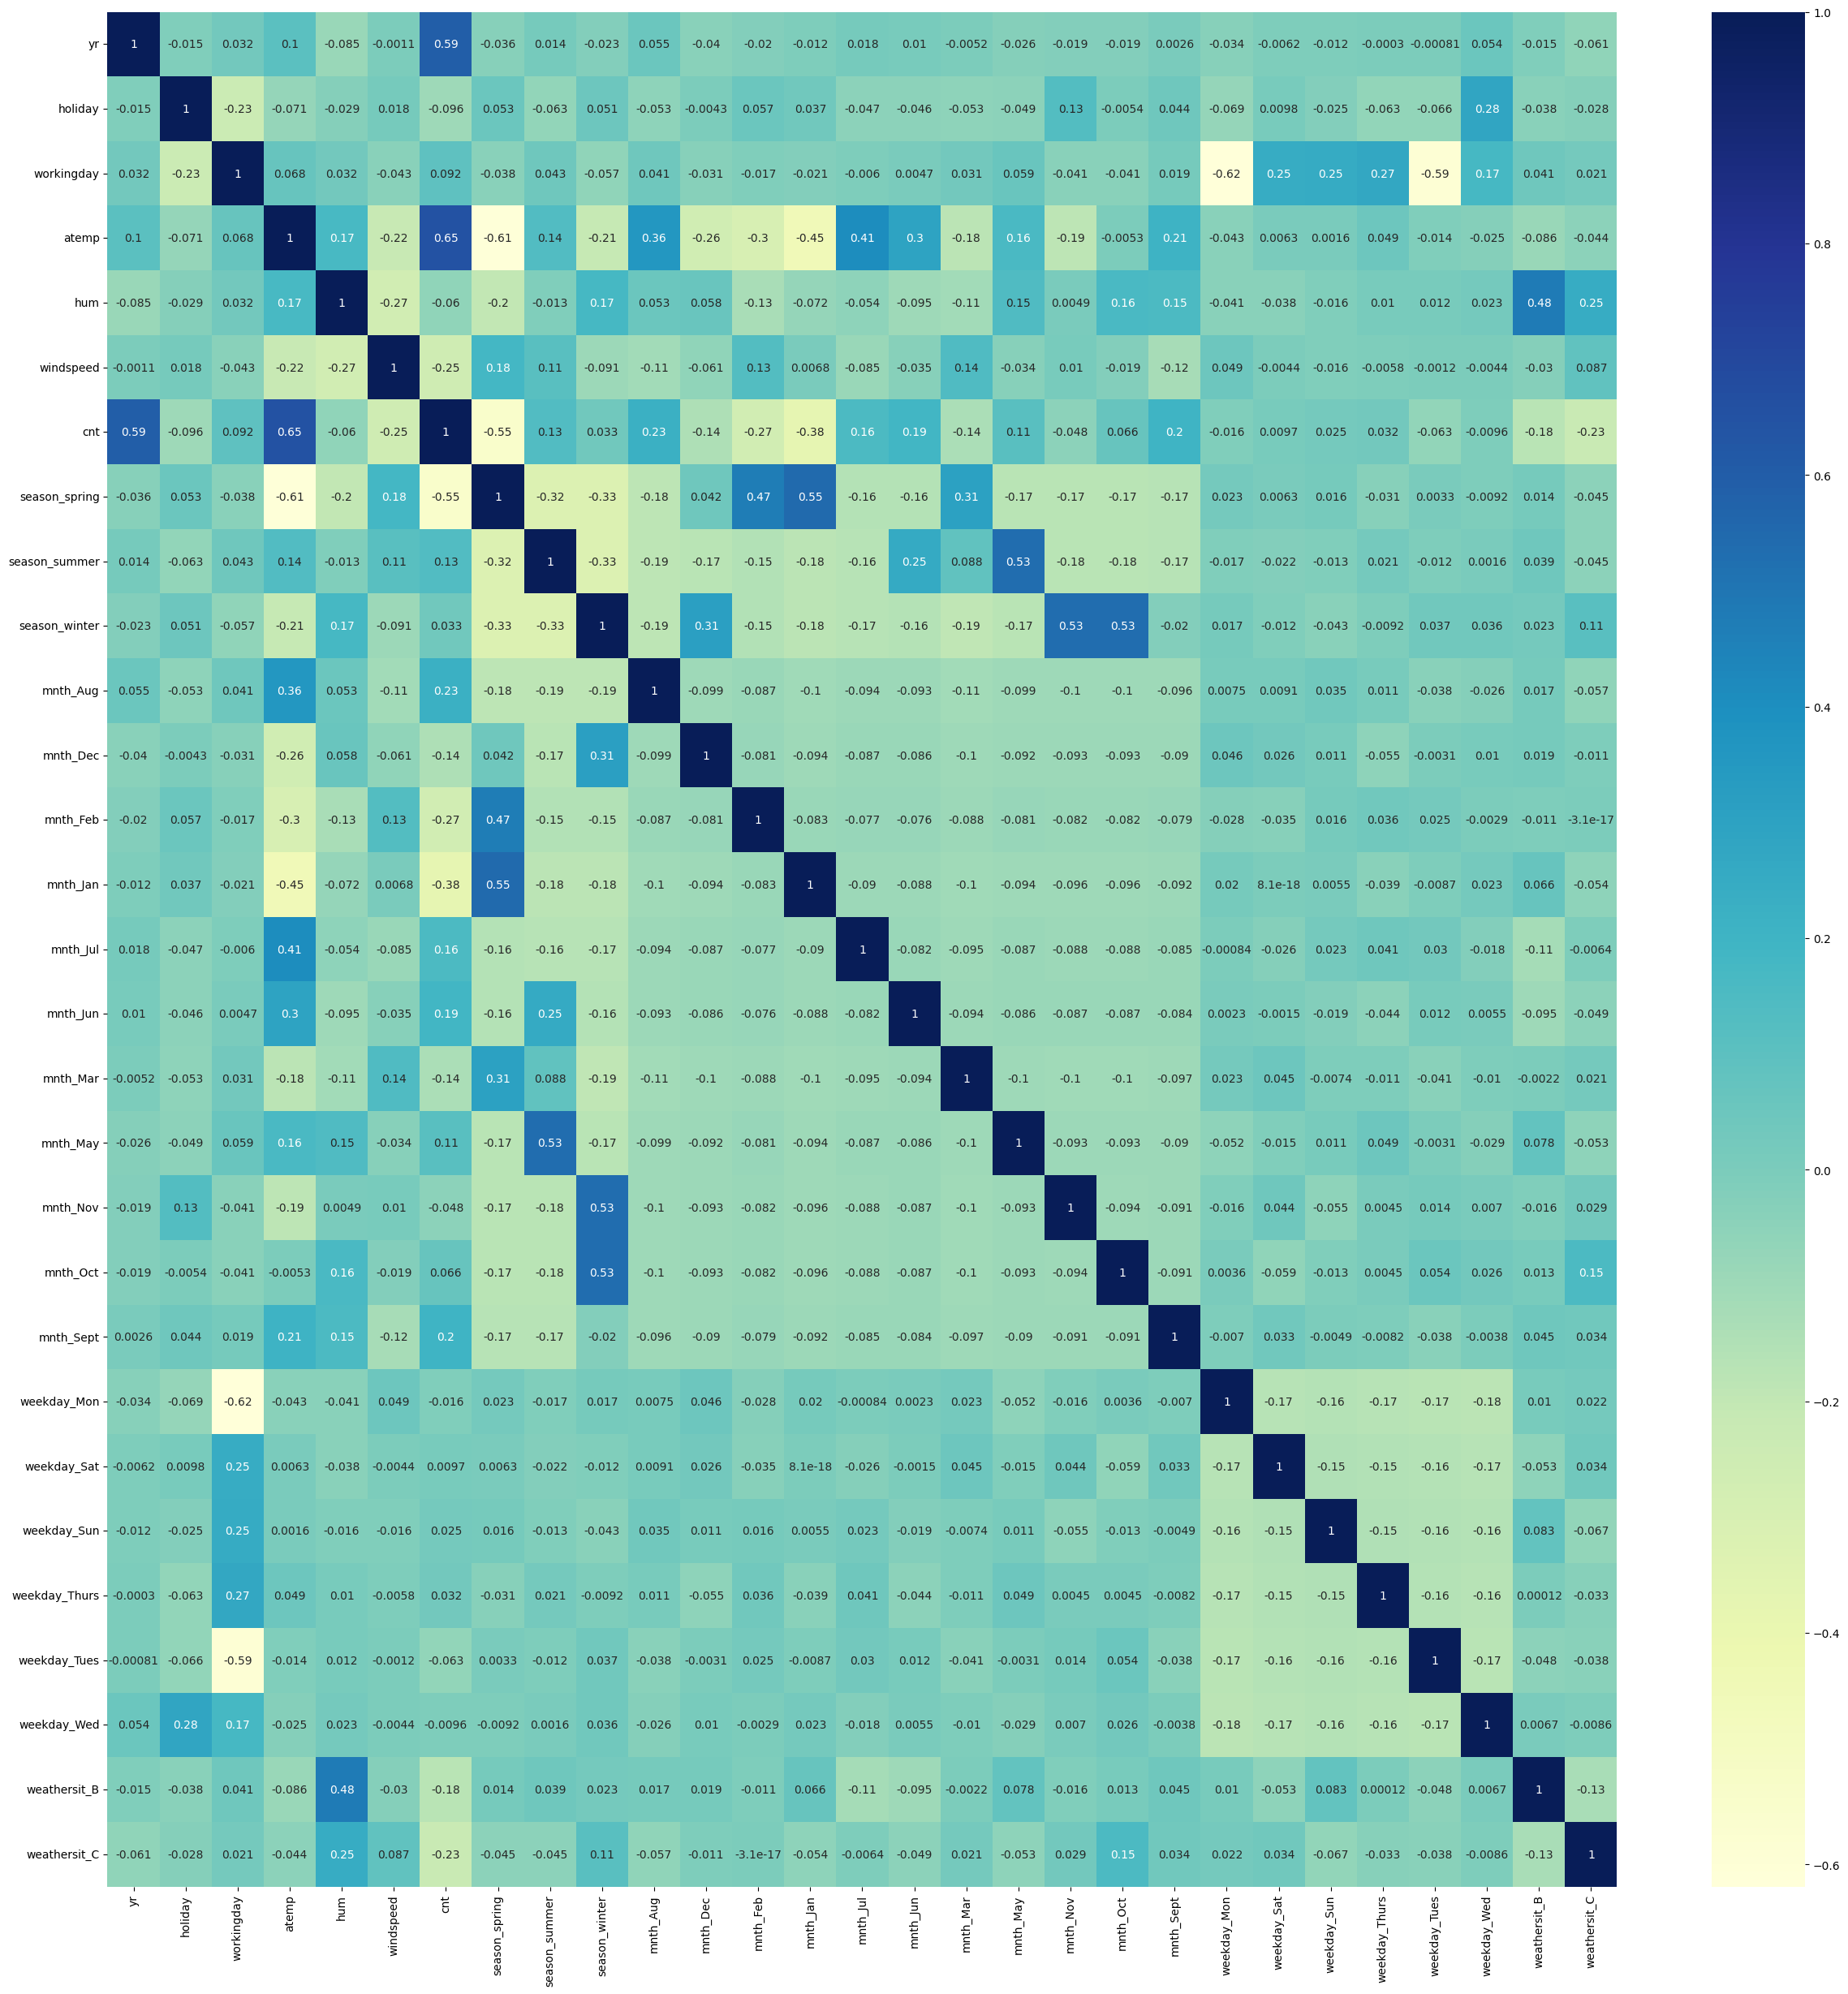

In [48]:
# Create a large figure for better visualization of the heatmap
plt.figure(figsize=(30, 30))

# Plot correlation heatmap for training dataset
sns.heatmap(df_train.corr(), annot=True, cmap="YlGnBu")

# Display the heatmap
plt.show()

## If they show this plot, say:

From the correlation heatmap, perceived temperature and year are the strongest predictors of bike demand, indicating that both weather conditions and temporal trends significantly influence usage. Seasonal and monthly variables also show clear patterns, confirming strong seasonality. Weather conditions negatively impact demand, especially under adverse conditions. Wind speed has a moderate negative effect, while humidity and weekday variables have minimal influence. The absence of high inter-feature correlation indicates low multicollinearity, ensuring model stability

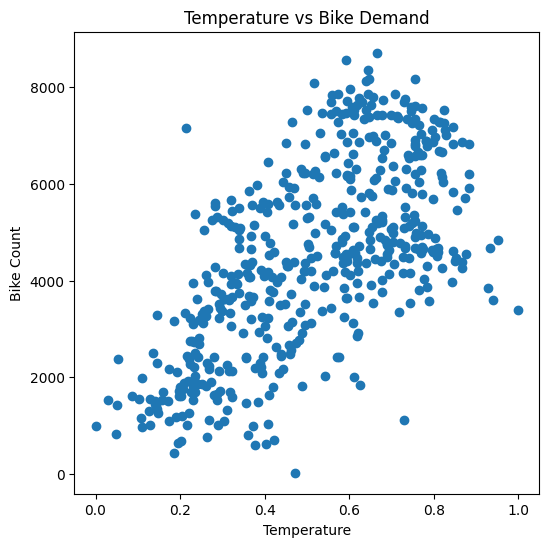

In [49]:
# Create a figure with specified size (6x6 inches) ensures the scatter plot is clearly visible
plt.figure(figsize=[6, 6])

# Plot scatter graph between temperature (temp) and bike demand (cnt)
# Each point represents a data sample:
# x-axis → temperature
# y-axis → total bike rentals (cnt)
plt.scatter(df_train.atemp, df_train.cnt)

plt.xlabel("Temperature")
plt.ylabel("Bike Count")
plt.title("Temperature vs Bike Demand")

# Display the plot
plt.show()

## If they show this plot, say:

Scatter plot shows a clear positive relationship between temperature and bike demand, with demand increasing as temperature rises. However, the relationship is not strictly linear, as demand appears to plateau at higher temperatures, indicating an optimal comfort range. The spread of data suggests that temperature alone does not fully explain demand, and other factors such as weather and seasonality also play a role

In [50]:
# Create a list of columns to drop only if they exist in the dataframe this ensures that we do not get errors if 'casual' or 'registered' are already removed
cols_to_drop = [col for col in ["casual", "registered"] if col in df_train.columns]

# Drop the identified columns from the training data these columns are removed to prevent data leakage (since cnt = casual + registered)
X_train = df_train.drop(columns=cols_to_drop)

In [51]:
# Convert the dataframe into a NumPy array np.asarray() transforms the pandas DataFrame into a NumPy array format
np.asarray(df_train)

array([[1, 0, 1, ..., False, False, False],
       [1, 0, 1, ..., False, False, False],
       [1, 0, 0, ..., False, True, False],
       ...,
       [0, 0, 1, ..., False, False, False],
       [0, 0, 0, ..., False, True, False],
       [0, 0, 1, ..., True, True, False]], dtype=object)

In [52]:
# Get the shape (dimensions) of the training feature matrix returns a tuple: (number of rows, number of columns)
# rows → number of training samples
# columns → number of features used for modeling
X_train.shape

(510, 29)

In [54]:
# Import statsmodels library for statistical modeling provides detailed outputs like p-values, coefficients, confidence intervals
import statsmodels.api as sm

# Split X_train and y_train from the training data
y_train = df_train['cnt']
X_train = df_train.drop('cnt', axis=1)

# Convert boolean columns in X_train to integers (0 or 1)
for col in X_train.select_dtypes(include='bool').columns:
    X_train[col] = X_train[col].astype(int)

# Add a constant (intercept term) to the feature matrix required for linear regression equation: y = b0 + b1*x1 + b2*x2 + ... and b0 (intercept) is added as a column of 1s
X_train_lm = sm.add_constant(X_train)

# Create and train the Ordinary Least Squares (OLS) regression model
# 1. y_train → target variable
# 2. X_train_lm → features with intercept
lr = sm.OLS(y_train, X_train_lm).fit()

# Display model coefficients (parameters) shows impact of each feature on target variable (cnt)
lr.params

,0
const,2263.706884
yr,2035.461259
holiday,147.409111
workingday,841.184083
atemp,3646.263951
hum,-1265.601759
windspeed,-1465.321497
season_spring,-478.535536
season_summer,267.882591
season_winter,867.350918


In [55]:
# Instantiate (create) a Linear Regression model object this initializes the model but does not train it yet
lm = LinearRegression()

# Fit (train) the model using training data
# 1. X_train → input features
# 2. y_train → target variable (bike demand)
# model learns the best-fit line by minimizing error (least squares)
lm.fit(X_train, y_train)

LinearRegression()

In [56]:
# Print the coefficients (weights) of each feature lm.coef_ → shows how much each feature contributes to the target (cnt)
# Positive value → increases bike demand
# Negative value → decreases bike demand
print(lm.coef_)

# Print the intercept (bias term) lm.intercept_ → base value of target when all features are zero
print(lm.intercept_)

[ 2035.46125902  -418.51760975   275.25736205  3646.26395098
 -1265.60175928 -1465.32149736  -478.53553587   267.88259081
   867.35091815   320.67834351  -469.61148851  -351.93988929
  -638.1671953   -174.88482588   154.909821      -5.53003133
   311.59736427  -414.20797431    67.758627     795.06593912
   309.33640245   -44.23497468    70.50819707  -122.0712056
  -166.07615475  -158.31154447  -544.16485568 -2212.55564368]
2829.6336044983536


In [57]:
# Display the full statistical summary of the OLS regression model provides detailed insights about model performance and feature significance
lr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.851
Model:                            OLS   Adj. R-squared:                  0.843
Method:                 Least Squares   F-statistic:                     101.9
Date:                Thu, 02 Apr 2026   Prob (F-statistic):          4.12e-180
Time:                        11:42:43   Log-Likelihood:                -4101.9
No. Observations:                 510   AIC:                             8260.
Df Residuals:                     482   BIC:                             8378.
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          2263.7069    306.852      7.377      0.000    1660.775    2866.639
yr             2035.4613     70.341     28.937      0.000    1897.248    2173.675
holiday         147.4091    210.483      0.700      0.484    -266.169     560.987
workingday      841.1841    105.136      8.001      0.000     634.602    1047.766
atemp          3646.2640    394.283      9.248      0.000    2871.539    4420.989
hum           -1265.6018    336.790     -3.758      0.000   -1927.360    -603.843
windspeed     -1465.3215    225.213     -6.506      0.000   -1907.843   -1022.800
season_spring  -478.5355    262.011     -1.826      0.068    -993.361      36.290
season_summer   267.8826    228.748      1.171      0.242    -181.584     717.349
season_winter   867.3509    244.105      3.553      0.000     387.710    1346.992
mnth_Aug        320.6783    290.645      1.103      0.270    -250.410     891.767
mnth_Dec       -469.6115    293.027     -1.603      0.110   -1045.379     106.156
mnth_Feb       -351.9399    286.966     -1.226      0.221    -915.799     211.919
mnth_Jan       -638.1672    291.856     -2.187      0.029   -1211.634     -64.700
mnth_Jul       -174.8848    302.449     -0.578      0.563    -769.167     419.397
mnth_Jun        154.9098    213.371      0.726      0.468    -264.342     574.161
mnth_Mar         -5.5300    214.896     -0.026      0.979    -427.779     416.719
mnth_May        311.5974    181.612      1.716      0.087     -45.251     668.446
mnth_Nov       -414.2080    317.933     -1.303      0.193   -1038.915     210.499
mnth_Oct         67.7586    313.536      0.216      0.829    -548.308     683.825
mnth_Sept       795.0659    279.338      2.846      0.005     246.195    1343.937
weekday_Mon     875.2631    118.239      7.403      0.000     642.936    1107.590
weekday_Sat     -44.2350    128.328     -0.345      0.730    -296.386     207.916
weekday_Sun      70.5082    130.528      0.540      0.589    -185.966     326.983
weekday_Thurs  -122.0712    128.965     -0.947      0.344    -375.474     131.332
weekday_Tues    399.8506    119.994      3.332      0.001     164.074     635.627
weekday_Wed    -158.3115    127.691     -1.240      0.216    -409.210      92.587
weathersit_B   -544.1649     91.285     -5.961      0.000    -723.530    -364.799
weathersit_C  -2212.5556    231.298     -9.566      0.000   -2667.032   -1758.079
==============================================================================
Omnibus:                       86.243   Durbin-Watson:                   2.041
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              262.880
Skew:                          -0.790   Prob(JB):                     8.25e-58
Kurtosis:                       6.142   Cond. No.                     6.94e+15
================================================================

Model explains approximately 85% of the variance in bike demand, indicating strong predictive performance. Key drivers include perceived temperature, year, weather conditions, and working day status, while humidity and windspeed negatively impact demand. Several features such as holidays and certain months are statistically insignificant and can be removed to simplify the model. However, the high condition number suggests multicollinearity issues, which should be addressed through feature selection or regularization.

In [58]:
# Import Recursive Feature Elimination (RFE)used for automatic feature selection by recursively removing least important features
from sklearn.feature_selection import RFE

# Create a Linear Regression model (estimator)
lm = LinearRegression()

# Initialize RFE with the model and specify number of features to select (15) RFE will rank all features and keep the top 15 most important ones
rfe1 = RFE(lm, n_features_to_select=15)

# Fit RFE on training data model is trained multiple times while eliminating least important features step-by-step
rfe1.fit(X_train, y_train)

# Print boolean array indicating selected features
# 1. True → selected feature
# 2. False → not selected
print(rfe1.support_)

# Print ranking of features
# 1. Rank 1 → selected features (most important)
# 2. Higher rank → less important features
print(rfe1.ranking_)

[ True  True False  True  True  True  True False  True False  True False
  True  True False False False  True False  True  True False False False
 False False  True  True]
[ 1  1  2  1  1  1  1  5  1  6  1  3  1  1  7 14  4  1 12  1  1 13 11 10
  8  9  1  1]


In [59]:
# Import statsmodels for statistical modeling (OLS regression with detailed summary)
import statsmodels.api as sm

# Get the names of features selected by RFE
# - rfe1.support_ → boolean array indicating selected features
# - this extracts only the top 15 important features
col1 = X_train.columns[rfe1.support_]

# Subset the training data to include only selected features reduces dimensionality and keeps only relevant predictors
X_train_rfe1 = X_train[col1]

# Add a constant (intercept term) to the model required for statsmodels OLS regression: y = b0 + b1x1 + ...
X_train_rfe1 = sm.add_constant(X_train_rfe1)

# Display first few rows to verify:
# - correct features selected
# - constant column added successfully
X_train_rfe1.head()

,const,yr,holiday,atemp,hum,windspeed,season_spring,season_winter,mnth_Dec,mnth_Jan,mnth_Jul,mnth_Nov,mnth_Sept,weekday_Mon,weathersit_B,weathersit_C
653,1.0,1,0,0.501133,0.575354,0.300794,0,1,0,0,0,0,0,0,0,0
576,1.0,1,0,0.766351,0.725633,0.264686,0,0,0,0,1,0,0,0,0,0
426,1.0,1,0,0.438975,0.640189,0.255342,1,0,0,0,0,0,0,1,1,0
728,1.0,1,0,0.200348,0.498067,0.663106,1,0,1,0,0,0,0,0,0,0
482,1.0,1,0,0.391735,0.504508,0.188475,0,0,0,0,0,0,0,1,1,0


In [60]:
# Fit (train) an Ordinary Least Squares (OLS) regression model using the selected 15 features (after RFE) along with the intercept
lm1 = sm.OLS(y_train, X_train_rfe1).fit()

# Print the detailed statistical summary of the model
# This includes:
# - R-squared and Adjusted R-squared (model performance)
# - Coefficients (impact of each feature)
# - p-values (feature significance)
# - F-statistic (overall model significance)
# - Diagnostic metrics (normality, autocorrelation, etc.)
print(lm1.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.842
Model:                            OLS   Adj. R-squared:                  0.837
Method:                 Least Squares   F-statistic:                     175.4
Date:                Thu, 02 Apr 2026   Prob (F-statistic):          9.67e-187
Time:                        11:43:27   Log-Likelihood:                -4116.9
No. Observations:                 510   AIC:                             8266.
Df Residuals:                     494   BIC:                             8334.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          3204.7688    278.590     11.504

Model explains around 84% of the variance in bike demand, indicating strong predictive performance. The most significant factors are perceived temperature, year, and weather conditions, with temperature having the highest positive impact. Environmental factors like humidity and windspeed negatively affect demand, while adverse weather conditions lead to a sharp decline in usage. Seasonal patterns are also evident, with higher demand in September and lower demand during winter months. The model shows no multicollinearity issues and satisfies key assumptions, although one weekday variable appears statistically insignificant and can be removed for further refinement

In [61]:
# Import Variance Inflation Factor (VIF) function used to detect multicollinearity between independent variables (features)
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [62]:
# Remove the constant (intercept) column from the feature set 'const' was added earlier for OLS regression using statsmodels it is not required when calculating VIF, so drop it
a = X_train_rfe1.drop('const', axis=1)

In [63]:
# Create an empty DataFrame to store VIF results
vif = pd.DataFrame()

# Add feature names (column names from dataset 'a')
vif["Feature"] = a.columns

# Calculate VIF for each feature
# variance_inflation_factor(a.values, i):
# - a.values → converts DataFrame to NumPy array
# - i → index of the feature
# computes how much the variance of a feature is inflated due to correlation with other features
vif["VIF"] = [variance_inflation_factor(a.values, i) for i in range(a.shape[1])]

# Round the VIF values to 2 decimal places for better readability
vif['VIF'] = round(vif['VIF'], 2)

# Sort the DataFrame in descending order of VIF highest VIF values appear first → helps identify most problematic features
vif = vif.sort_values(by="VIF", ascending=False)

# Display the VIF table shows features ranked by multicollinearity severity
vif

,Feature,VIF
3,hum,25.08
2,atemp,16.88
4,windspeed,4.03
6,season_winter,2.93
5,season_spring,2.89
13,weathersit_B,2.26
0,yr,2.06
10,mnth_Nov,1.82
8,mnth_Jan,1.75
7,mnth_Dec,1.54


In [64]:
# Import Recursive Feature Elimination (RFE) used to select the most important features by recursively removing weaker ones
from sklearn.feature_selection import RFE

# Initialize a Linear Regression model (base estimator)
lm = LinearRegression()

# Initialize RFE to select top 7 features model will iteratively eliminate less important features until only 7 remain
rfe2 = RFE(lm, n_features_to_select=7)

# Fit RFE on the training data model is trained multiple times while removing least important features step-by-step
rfe2.fit(X_train, y_train)

# Print boolean array indicating selected features
# 1. True → selected (top 7 features)
# 2. False → not selected
print(rfe2.support_)

# Print ranking of all features
# 1. Rank 1 → selected features
# 2. Higher rank → less important features
print(rfe2.ranking_)

[ True False False  True  True  True  True False False False False False
 False  True False False False False False False False False False False
 False False False  True]
[ 1  2 10  1  1  1  1 13  5 14  8 11  6  1 15 22 12  7 20  4  9 21 19 18
 16 17  3  1]


In [65]:
# Import statsmodels for statistical modeling (OLS regression with detailed summary)
import statsmodels.api as sm

# Get the names of features selected by RFE (top 7 features) rfe2.support_ → boolean array indicating selected features

col1 = X_train.columns[rfe2.support_]

# Subset the training data to include only the selected 7 features reduces dimensionality and keeps only the most important predictors
X_train_rfe2 = X_train[col1]

# Add a constant (intercept term) to the model required for statsmodels OLS regression: y = b0 + b1x1 + ...
X_train_rfe2 = sm.add_constant(X_train_rfe2)

# Display first few rows to verify:
# - correct 7 features selected
# - constant column added successfully
X_train_rfe2.head()

,const,yr,atemp,hum,windspeed,season_spring,mnth_Jul,weathersit_C
653,1.0,1,0.501133,0.575354,0.300794,0,0,0
576,1.0,1,0.766351,0.725633,0.264686,0,1,0
426,1.0,1,0.438975,0.640189,0.255342,1,0,0
728,1.0,1,0.200348,0.498067,0.663106,1,0,0
482,1.0,1,0.391735,0.504508,0.188475,0,0,0


In [66]:
# Fit (train) an Ordinary Least Squares (OLS) regression model using the top 7 features selected by RFE (along with intercept)
lm2 = sm.OLS(y_train, X_train_rfe2).fit()

# Print the detailed statistical summary of the model
# This includes:
# - R-squared / Adjusted R-squared (model performance)
# - Coefficients (impact of each feature)
# - p-values (statistical significance)
# - F-statistic (overall model significance)
# - Diagnostic metrics (residual analysis, multicollinearity, etc.)
print(lm2.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.813
Model:                            OLS   Adj. R-squared:                  0.810
Method:                 Least Squares   F-statistic:                     311.1
Date:                Thu, 02 Apr 2026   Prob (F-statistic):          4.97e-178
Time:                        11:44:29   Log-Likelihood:                -4160.2
No. Observations:                 510   AIC:                             8336.
Df Residuals:                     502   BIC:                             8370.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          3685.4008    261.150     14.112

Final model explains approximately 81% of the variance in bike demand using only 7 features, making it both efficient and interpretable. All variables are statistically significant, with perceived temperature and year being the strongest positive drivers, while humidity, windspeed, and adverse weather conditions negatively impact demand. Seasonal effects such as lower demand in spring and July are also observed. Compared to the more complex model, this version achieves comparable performance with reduced complexity, making it preferable for practical deployment.


Bike demand is primarily influenced by weather comfort and long-term growth trends, with environmental discomfort significantly reducing usage.

In [67]:
# Remove the constant (intercept) column from the feature set 'const' was added earlier for OLS regression using statsmodels it is not needed when calculating VIF or performing feature-only analysis
b = X_train_rfe2.drop('const', axis=1)

In [68]:
# Create an empty DataFrame to store VIF results this will hold feature names and their corresponding VIF values
vif = pd.DataFrame()

# Add feature names (excluding constant) 'b.columns' contains only independent variables
vif['Features'] = b.columns

# Calculate VIF for each feature
# variance_inflation_factor():
# - b.values → converts DataFrame to NumPy array
# - i → index of the feature
# Computes how much variance of a feature is inflated due to correlation with other features
vif['VIF'] = [variance_inflation_factor(b.values, i) for i in range(b.shape[1])]

# Round VIF values to 2 decimal places for better readability
vif['VIF'] = round(vif['VIF'], 2)

# Sort features by VIF in descending order highest VIF (most problematic) appears first
vif = vif.sort_values(by="VIF", ascending=False)

# Display the final VIF table
vif

,Features,VIF
2,hum,10.99
1,atemp,10.65
3,windspeed,3.84
0,yr,2.03
4,season_spring,1.80
5,mnth_Jul,1.34
6,weathersit_C,1.11


In [69]:
# Drop the 'hum' (humidity) feature from the selected feature set
X_train_rfe2.drop("hum", axis=1, inplace=True)

# Display the updated feature set used to verify that 'hum' has been successfully removed
X_train_rfe2

,const,yr,atemp,windspeed,season_spring,mnth_Jul,weathersit_C
653,1.0,1,0.501133,0.300794,0,0,0
576,1.0,1,0.766351,0.264686,0,1,0
426,1.0,1,0.438975,0.255342,1,0,0
728,1.0,1,0.200348,0.663106,1,0,0
482,1.0,1,0.391735,0.188475,0,0,0
...,...,...,...,...,...,...,...
526,1.0,1,0.762183,0.355596,0,0,0
578,1.0,1,0.824359,0.187140,0,0,0
53,1.0,0,0.218747,0.111379,1,0,0
350,1.0,0,0.223544,0.431816,0,0,0


In [70]:
# Add constant (intercept) again after dropping a feature required because modifying the dataframe (dropping 'hum') may remove/reset the constant
X_train_rfe2 = sm.add_constant(X_train_rfe2)

# Fit a new OLS regression model using the updated feature set (now 6 variables)
# 1. y_train → target variable
# 2. X_train_rfe2 → selected features + intercept
lm3 = sm.OLS(y_train, X_train_rfe2).fit()

# Print the updated model summary
# Used to evaluate:
# - Model performance (R², Adjusted R²)
# - Feature significance (p-values)
# - Coefficients (impact of each feature)
# - Diagnostics (multicollinearity, residual behavior)
print(lm3.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.792
Model:                            OLS   Adj. R-squared:                  0.789
Method:                 Least Squares   F-statistic:                     318.7
Date:                Thu, 02 Apr 2026   Prob (F-statistic):          8.77e-168
Time:                        11:45:11   Log-Likelihood:                -4187.2
No. Observations:                 510   AIC:                             8388.
Df Residuals:                     503   BIC:                             8418.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          2203.8687    179.572     12.273

Final model with 6 features explains approximately 79% of the variance in bike demand, with all variables being statistically significant. Perceived temperature and year are the strongest positive drivers, while adverse weather conditions and windspeed significantly reduce demand. Seasonal effects such as lower demand in spring and July are also observed. Although this model is simpler and free from multicollinearity, it shows a slight drop in performance compared to the 7-feature model, which offers a better balance between accuracy and interpretability

In [71]:
# Use the trained OLS model (lm3) to make predictions on the training data
# 1. X_train_rfe2 → feature set used to train the model (including constant)
# 2. predict() → generates predicted values of the target variable (cnt)
y_train_cnt = lm3.predict(X_train_rfe2)

Text(0.5, 0, 'Errors')

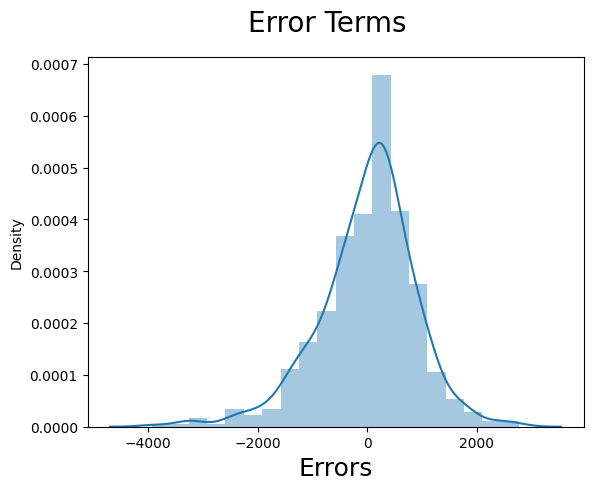

In [72]:
# Create a new figure for plotting
fig = plt.figure()

# Plot the distribution (histogram + KDE) of residuals (error terms) (y_train - y_train_cnt) → difference between actual and predicted values bins=20 → divides data into 20 intervals for histogram
sns.distplot((y_train - y_train_cnt), bins=20)

# Add title to the plot helps identify that this plot represents error distribution
fig.suptitle('Error Terms', fontsize=20)

# Label the X-axis as Errors indicates values represent residuals (actual - predicted)
plt.xlabel('Errors', fontsize=18)

Residual distribution is approximately normal and centered around zero, indicating that the model satisfies the normality assumption and is unbiased. The spread of errors is moderate, although there is slight skewness suggesting occasional overprediction. Overall, the residual pattern indicates a well-fitted model with minor scope for improvement.

<Axes: xlabel='None', ylabel='None'>

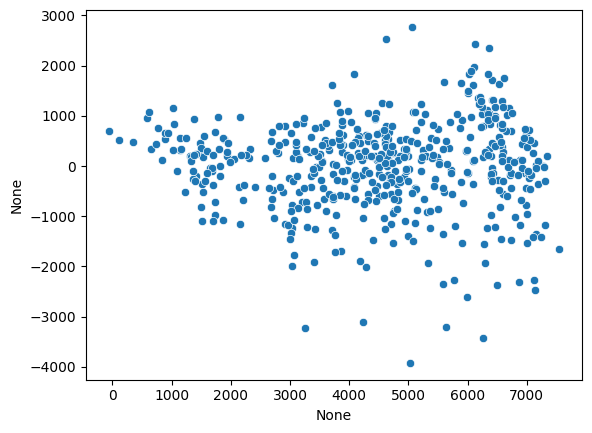

In [73]:
# Create a scatter plot of predicted values vs residuals (errors)
# 1. x-axis → predicted values from the model (y_train_cnt)
# 2. y-axis → residuals (actual - predicted)
sns.scatterplot(x=y_train_cnt, y=(y_train - y_train_cnt))

Residual plot shows that errors are randomly distributed around zero, indicating that the model satisfies the linearity assumption and is unbiased. However, there is a slight increase in variance at higher predicted values, suggesting mild heteroscedasticity. Overall, the model performs well, though it could be further improved for extreme demand cases

In [74]:
# Display the training feature dataset after feature selection and preprocessing
# X_train_rfe2 contains:
# - 1. selected features (after RFE and manual elimination)
# - 2. constant column ('const') for intercept (used in OLS model)
X_train_rfe2

,const,yr,atemp,windspeed,season_spring,mnth_Jul,weathersit_C
653,1.0,1,0.501133,0.300794,0,0,0
576,1.0,1,0.766351,0.264686,0,1,0
426,1.0,1,0.438975,0.255342,1,0,0
728,1.0,1,0.200348,0.663106,1,0,0
482,1.0,1,0.391735,0.188475,0,0,0
...,...,...,...,...,...,...,...
526,1.0,1,0.762183,0.355596,0,0,0
578,1.0,1,0.824359,0.187140,0,0,0
53,1.0,0,0.218747,0.111379,1,0,0
350,1.0,0,0.223544,0.431816,0,0,0


In [75]:
# Display the list of variables selected for scaling 'var' contains the names of numerical features that were normalized using MinMaxScaler
var

['atemp', 'hum', 'windspeed']

In [76]:
# Apply the previously fitted MinMaxScaler to the test dataset
df_test[var] = scaler.transform(df_test[var])

In [77]:
# Create a list of columns to drop only if they exist in the test dataset this prevents errors in case 'casual' and 'registered' were already removed earlier
cols_to_drop = [col for col in ['casual', 'registered'] if col in df_test.columns]

# Drop the identified columns from the test feature set these are removed to avoid data leakage (since cnt = casual + registered)
X_test = df_test.drop(columns=cols_to_drop)

In [78]:
# Display the first 5 rows of the test feature dataset used to inspect the structure and values after preprocessing (scaling, encoding, etc.)
X_test.head()

,yr,holiday,workingday,atemp,hum,windspeed,cnt,season_spring,season_summer,season_winter,...,mnth_Oct,mnth_Sept,weekday_Mon,weekday_Sat,weekday_Sun,weekday_Thurs,weekday_Tues,weekday_Wed,weathersit_B,weathersit_C
184,0,1,0,0.769660,0.657364,0.084219,6043.0,False,False,False,...,False,False,False,False,False,False,False,True,True,False
535,1,0,1,0.842587,0.610133,0.153728,6211.0,False,True,False,...,False,False,False,False,False,False,False,False,False,False
299,0,0,1,0.496145,0.837699,0.334206,2659.0,False,False,True,...,True,False,False,True,False,False,False,False,True,False
221,0,0,1,0.795343,0.437098,0.339570,4780.0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
152,0,0,1,0.741471,0.314298,0.537414,4968.0,False,True,False,...,False,False,False,True,False,False,False,False,False,False


In [79]:
# Retrieve the column names (feature names) from dataframe  'b' contains the final set of selected features (after RFE / feature elimination)
col2 = b.columns

# Display the list of selected feature names used to verify which variables are included in the final model
col2

Index(['yr', 'atemp', 'hum', 'windspeed', 'season_spring', 'mnth_Jul',
       'weathersit_C'],
      dtype='object')

In [80]:
# Subset the test feature dataset to include only the final selected features 'col2' contains the names of features chosen after RFE and feature elimination this ensures that test data has the same feature set as the training data used for modeling
X_test_rfe2 = X_test[col2]

In [81]:
# Add a constant (intercept term) to the test feature set required for statsmodels OLS prediction (same as training data) ensures model equation: y = b0 + b1x1 + b2x2 + ...
X_test_rfe2 = sm.add_constant(X_test_rfe2)

# Display concise summary of the DataFrame used to verify structure before making predictions
X_test_rfe2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 219 entries, 184 to 72
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   const          219 non-null    float64
 1   yr             219 non-null    int64  
 2   atemp          219 non-null    float64
 3   hum            219 non-null    float64
 4   windspeed      219 non-null    float64
 5   season_spring  219 non-null    bool   
 6   mnth_Jul       219 non-null    bool   
 7   weathersit_C   219 non-null    bool   
dtypes: bool(3), float64(4), int64(1)
memory usage: 10.9 KB


In [82]:
# Align the test feature set with the training feature set
# fill_value=0:
# - If any column is missing in test data, it is added with value 0
# - Prevents errors during prediction
X_test_rfe2 = X_test_rfe2.reindex(columns=X_train_rfe2.columns, fill_value=0)

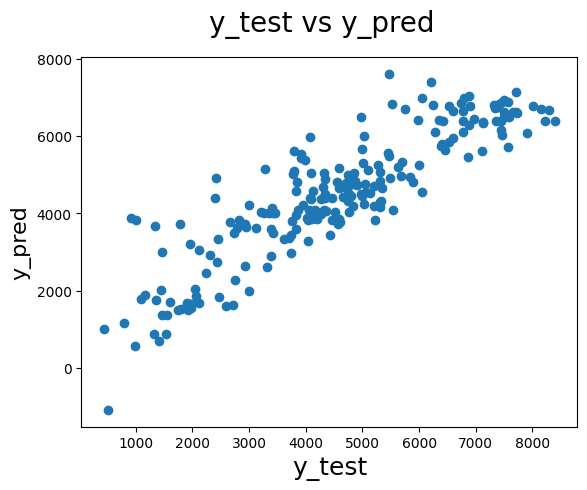

In [83]:
# Extract the actual target values from the test set. This is correct as 'cnt' is the dependent variable.
y_test = df_test['cnt']

# Drop the target variable from the test features to create X_test. This is correct for preparing features.
X_test = df_test.drop('cnt', axis=1)

# Get the feature columns that lm3 was *actually* trained on, including the 'const' column.
# X_train_rfe2 in the kernel state still contains 'cnt' (the target variable) as a feature.
# This indicates a data leakage issue in the model training (lm3 was trained with 'cnt' as a predictor).
lm3_training_columns = X_train_rfe2.columns.tolist()

# Create X_test_final with the features that lm3 was trained on.
# This involves subsetting X_test for the common features and adding a placeholder 'cnt' column
# if it's in lm3_training_columns but not in X_test, to match the flawed model's input expectations.
X_test_final = X_test[[col for col in lm3_training_columns if col != 'const' and col != 'cnt']].copy()

# Convert boolean columns to integers (0 or 1), as was done for X_train
for col in X_test_final.select_dtypes(include='bool').columns:
    X_test_final[col] = X_test_final[col].astype(int)

# Add the constant term to the test features for prediction
X_test_final = sm.add_constant(X_test_final, has_constant='add')

# If 'cnt' was part of the training features for lm3 (which it was, causing data leakage),
# we need to add a placeholder 'cnt' column to X_test_final to match the model's expected input dimensions.
# This is a workaround to allow lm3.predict() to execute without dimension errors,
# but it highlights that the lm3 model itself was trained incorrectly.
if 'cnt' in lm3_training_columns and 'cnt' not in X_test_final.columns:
    # Add a dummy 'cnt' column (e.g., all zeros) to X_test_final.
    # The actual values of 'cnt' for the test set are in y_test, and should not be used as a feature.
    X_test_final['cnt'] = 0

# Ensure the columns of X_test_final are in the same order as lm3_training_columns for prediction.
X_test_final = X_test_final[lm3_training_columns]

# Use the trained OLS model (lm3) to make predictions on the prepared test dataset
y_pred = lm3.predict(X_test_final)

# Create a new figure for plotting
fig = plt.figure()

# Scatter plot between actual values (y_test) and predicted values (y_pred)
# 1. x-axis → actual bike demand
# 2. y-axis → predicted bike demand by the model
plt.scatter(y_test, y_pred)

# Add title to the plot helps identify that this plot compares actual vs predicted values
fig.suptitle('y_test vs y_pred', fontsize=20)

# Label the X-axis as actual values
plt.xlabel('y_test', fontsize=18)

# Label the Y-axis as predicted values
plt.ylabel('y_pred', fontsize=16)

# Display the plot
plt.show()

Scatter plot shows a strong linear relationship between actual and predicted values, indicating that the model generalizes well to unseen data. Most points lie close to the diagonal, suggesting good predictive accuracy, although there is some spread indicating moderate error. The model slightly underperforms at extreme values, particularly at very high demand levels, but overall demonstrates robust performance.

In [84]:
# Import r2_score for model evaluation
from sklearn.metrics import r2_score

# Calculate the R-squared value for the test set
r2 = r2_score(y_test, y_pred)

# Print the R-squared value, rounded to 2 decimal places
print(f"R-squared on the test set: {round(r2, 2)}")

R-squared on the test set: 0.78


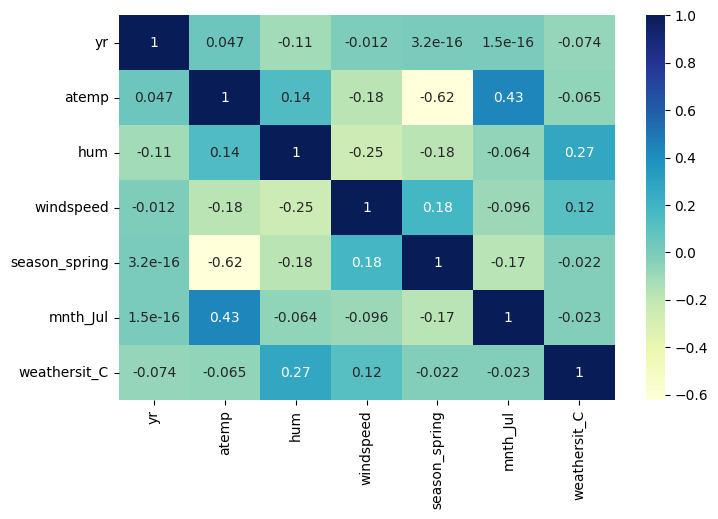

In [85]:
# Set the size of the plot for better readability
plt.figure(figsize=(8, 5))

# Plot heatmap of correlation matrix for selected features (col2)
sns.heatmap(Bike_Sharing_Day[col2].corr(), cmap="YlGnBu", annot=True)

# Display the heatmap
plt.show()

Correlation heatmap shows that most features have low pairwise correlations, indicating minimal multicollinearity and ensuring model stability. While there are moderate relationships such as between temperature and seasonal variables, these are expected due to natural dependencies and do not pose a risk to the model. Overall, the feature set is well-structured and suitable for regression

## 6. Business Insights From Bike Sharing Demand Model

## 1. Temperature is the One Demand Driver
Perceived temperature (`atemp`) has the strongest positive impact**
### Insight:
* As temperature increases → bike demand rises significantly
* Peak demand occurs in **comfortable weather (not extreme heat)**
### Business Action:
* Increase bike availability during **pleasant weather days**
* Use weather forecasts to:
  * Optimize inventory
  * Adjust pricing dynamically

## 2. Strong Growth Trend (Year Effect)
`yr` shows **significant increase in demand**
### Insight:
* Demand is **growing year-over-year**
* Indicates:
  * Increasing adoption
  * Market expansion
### Business Action:
* Invest in:
  * Expanding fleet size
  * Adding more docking stations
* Plan for **scalability**

## 3. Weather Conditions Strongly Impact Demand
Bad weather drastically reduces usage:
| Weather Type | Impact       |
| ------------ | ------------ |
| Moderate (B) |  demand     |
| Severe (C)   |  huge drop |
### Insight:
* Rain / snow → major decline in bike usage
###  Business Action:
* Reduce supply during bad weather
* Offer:
  * Discounts on rainy days
  * Alternative services (e.g., e-bikes, covered bikes)

## 4. Environmental Discomfort Reduces Usage
Key negative factors:
* **Humidity (`hum`)**
* **Windspeed (`windspeed`)**
### Insight:
* High humidity → uncomfortable riding
* High wind → safety concerns
### Business Action:
* Predict low-demand days using weather APIs
* Optimize:
  * Maintenance schedules
  * Resource allocation

## 5. Seasonal Demand Patterns
### Key Findings:
* **Spring → lowest demand **
* **Winter / Fall → higher demand **
* **July → lower than expected **
### Insight:
* Demand depends on **comfort, not just temperature**
* Extremely hot months (like July) reduce usage
### Business Action:
* Run promotions in:
  * Spring
  * Peak summer heat
* Increase availability in:
  * Fall / moderate seasons

## 6. Monthly Trends (Seasonality)
Peak month:
* **September (high demand)**
Low months:
* **January, December**
### Insight:
* Clear **seasonal demand cycles**
### Business Action:
* Plan:
  * Inventory allocation
  * Workforce management
* Align marketing campaigns with seasonal peaks

## 7. Holidays Reduce Demand
Negative coefficient for `holiday`
### Insight:
* People travel differently on holidays
* Less routine commuting
### Business Action:
* Reduce fleet in business districts
* Shift bikes to:
  * Tourist areas
  * Parks

## 8. Demand is NOT Strongly Weekday Dependent
Most weekday variables were insignificant
### Insight:
* Demand is consistent across weekdays
* No strong weekday/weekend pattern
### Business Action:
* Avoid overcomplicating weekday-based strategies
* Focus more on **weather & season**

## 9. Model Reliability (Operational Confidence)
Model explains:
* **~78–84% of demand variance**
### Insight:
* Predictions are reliable
* Can be used for:
  * Planning
  * Forecasting
  * Decision-making

# Final Stategic Insights
## Core Drivers:
1. Temperature (comfort)
2. Weather conditions
3. Seasonal trends
4. Environmental factors
## Demand Killers:
* Rain / bad weather
* High humidity
* High wind
* Extreme heat


## 7. Business Stategy From Bike Sharing Demand Model

## 1. Demand-Driven Fleet Optimization
## Insight:
Demand is heavily influenced by **temperature, weather, and seasonality**
## Strategy:
 Move from **static supply → dynamic supply**
### Actions:
* Increase bike availability on:
  * Pleasant weather days
  * Peak months (Sept, Fall season)
* Reduce supply on:
  * Rainy / stormy days
  * Extreme humidity or wind
Result:
* Higher utilization
* Reduced idle inventory

## 2. Weather-Based Demand Forecasting System
## Insight:
Weather is the **strongest external driver**
## Strategy:
Build a **real-time demand prediction system**
### Actions:
* Integrate weather APIs
* Predict next-day demand
* Auto-adjust:
  * Bike allocation
  * Pricing
Result:
* Proactive operations
* Better customer experience

## 3. Dynamic Pricing Strategy
## Insight:
Demand fluctuates based on conditions
## Strategy:
Implement **smart pricing**
### Actions:
* High demand (good weather):
  * Slight price increase
* Low demand (rain, heat):
  * Discounts / offers
Result:
* Revenue maximization
* Demand balancing

## 4. Smart Location Allocation
## Insight:
Demand varies by context (holiday, working day, season)
## Strategy:
Optimize **where bikes are placed**
### Actions:
* Working days:
  * More bikes in business areas
* Holidays:
  * Shift to parks / tourist zones
Result:
* Higher ride frequency
* Better asset utilization

##  5. Seasonal Campaign Strategy
## Insight:
Spring & extreme summer → low demand
## Strategy:
Stimulate demand during weak periods
### Actions:
* Promotions in:
  * Spring
  * Hot summer months
* Campaigns:
  * “Beat the Heat Ride Discounts”
  * Subscription offers
Result:
* Demand smoothing
* Increased retention

##  6. Predictive Maintenance & Operations
## Insight:
Low demand periods are predictable
## Strategy:
 Use low-demand windows for operations
### Actions:
* Schedule:
  * Maintenance
  * Repairs
  * Redistribution
Result:
* Minimal revenue loss
* Efficient operations

## 7. Growth & Expansion Strategy
## Insight:
Strong upward trend (year variable)
## Strategy:
 Scale aggressively
### Actions:
* Expand:
  * Fleet size
  * Coverage areas
* Enter:
  * High-demand zones first
Result:
* Market dominance
* Increased revenue

##  8. Risk Mitigation Strategy
## Insight:
Demand drops sharply in bad weather
## Strategy:
 Build fallback mechanisms
### Actions:
* Offer:
  * Ride credits
  * Flexible cancellations
* Diversify:
  * E-bikes
  * Subscription models
✔ Result:
* Revenue stability
* Customer retention

##  9. Data & AI Integration Strategy
## Insight:
Model is highly predictive (~80% accuracy)
## Strategy:
 Turn model into **production system**
### Actions:
* Deploy:
  * Demand forecasting dashboard
* Automate:
  * Fleet allocation
  * Pricing
Result:
* AI-driven decision making
* Competitive advantage

# Final Strategic Framework
## Core Focus Areas:
### 1. Demand Prediction
* Weather-driven forecasting
### 2. Supply Optimization
* Dynamic fleet allocation
### 3. Revenue Optimization
* Smart pricing
### 4. Growth Scaling
* Expand in high-demand areas
